In [1]:
!pip install kagglehub

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import os
import shutil
import numpy as np
import seaborn as sns

d:\BeData\SMK Telkom\Project Analisis Data\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
directory_path = "datasets"
os.makedirs(directory_path, exist_ok=True)
download_path = kagglehub.dataset_download("jockeroika/life-style-data")

for file in os.listdir(download_path):
    src_file = os.path.join(download_path, file)
    dst_file = os.path.join(directory_path, file)
    shutil.copy2(src_file, dst_file)

path = directory_path

| Nama Kolom | Deskripsi |
| :--- | :--- |
| Age | Usia partisipan (dalam tahun). |
| Gender | Jenis kelamin biologis (Pria/Wanita). |
| Weight (kg) | Berat individu dalam kilogram. |
| Height (m) | Tinggi individu dalam meter. |
| Max\_BPM | Denyut jantung maksimum yang tercatat selama sesi latihan. |
| Avg\_BPM | Denyut jantung rata-rata yang dipertahankan selama sesi. |
| Resting\_BPM | Denyut jantung istirahat sebelum memulai latihan. |
| Session\_Duration (hours) | Durasi sesi latihan dalam jam. |
| Calories\_Burned | Total kalori yang terbakar selama sesi. |
| Workout\_Type | Jenis latihan yang dilakukan (misalnya, Kekuatan, HIIT, Kardio). |
| Fat\_Percentage | Persentase lemak tubuh individu. |
| Water\_Intake (liters) | Rata-rata konsumsi air harian dalam liter. |
| Workout\_Frequency (days/week) | Jumlah hari latihan per minggu. |
| Experience\_Level | Tingkat pengalaman kebugaran (1=Pemula, 2=Menengah, 3=Mahir). |
| BMI | Indeks Massa Tubuh (IMT), ukuran lemak tubuh berdasarkan tinggi dan berat. |
| Daily meals frequency | Jumlah porsi makan yang dikonsumsi setiap hari. |
| Physical exercise | Menunjukkan jenis atau frekuensi aktivitas fisik. |
| Carbs | Asupan karbohidrat harian (gram). |
| Proteins | Asupan protein harian (gram). |
| Fats | Asupan lemak harian (gram). |
| Calories | Total asupan kalori harian dari makanan. |
| meal\_name | Nama makanan (misalnya, Sarapan, Makan Siang, Makan Malam). |
| meal\_type | Jenis makanan (misalnya, Camilan, Utama, Minuman). |
| diet\_type | Jenis diet yang diikuti (misalnya, Keto, Vegan, Seimbang). |
| sugar\_g | Kandungan gula dalam gram per porsi makan. |
| sodium\_mg | Kandungan sodium dalam miligram per porsi makan. |
| cholesterol\_mg | Kandungan kolesterol dalam miligram per porsi makan. |
| serving\_size\_g | Ukuran porsi makanan dalam gram. |
| cooking\_method | Metode memasak yang digunakan (misalnya, Rebus, Goreng, Panggang). |
| prep\_time\_min | Waktu persiapan dalam menit. |
| cook\_time\_min | Waktu memasak dalam menit. |
| rating | Peringkat makanan atau latihan (biasanya skala 1–5). |
| is\_healthy | Indikator Boolean (True/False) apakah makanan/latihan itu sehat. |
| Name of Exercise | Nama latihan yang dilakukan. |
| Sets | Jumlah set yang diselesaikan dalam latihan. |
| Reps | Jumlah repetisi per set. |
| Benefit | Deskripsi manfaat fisik dari latihan. |
| Burns Calories (per 30 min) | Estimasi kalori yang terbakar dalam 30 menit latihan tersebut. |
| Target Muscle Group | Grup otot utama yang ditargetkan oleh latihan. |
| Equipment Needed | Peralatan yang diperlukan untuk melakukan latihan. |
| Difficulty Level | Tingkat kesulitan latihan (Pemula, Menengah, Mahir). |
| Body Part | Bagian tubuh utama yang terlibat (misalnya, Lengan, Kaki, Dada). |
| Type of Muscle | Jenis otot yang dilatih (misalnya, Atas, Inti, Kekuatan Cengkeraman). |
| Workout | Latihan atau olahraga spesifik. |

In [4]:
meal_metadata = pd.read_csv(os.path.join(path, "meal_metadata.csv"))
meal_metadata

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin
0,34.91,Male,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,Strength,...,2139.59,0.500432,1.624789,0.741237,0.835985,725.10,47.777394,685.1600,7.260425e+19,Medium
1,23.37,Female,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,HIIT,...,1711.65,0.500850,1.514093,0.551247,0.734270,-232.91,40.809803,978.6184,1.020506e+20,High
2,33.20,Female,58.98,1.67,175.04,123.95,54.96,0.91,802.26,Cardio,...,1965.92,0.500610,1.663445,0.574534,0.708124,805.74,44.635580,654.5266,1.079607e+20,High
3,38.69,Female,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,HIIT,...,1627.28,0.499533,0.862017,0.744155,0.811150,1206.21,63.007432,773.6300,8.987921e+19,High
4,45.09,Male,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,Strength,...,2659.23,0.500581,2.538153,0.668405,0.789751,303.60,43.347504,711.4176,5.264685e+19,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,54.23,Female,55.50,1.71,163.93,152.05,67.07,0.79,954.16,HIIT,...,2288.95,0.498150,2.077477,0.877349,0.927530,359.84,43.149064,555.3068,8.948330e+19,High
164,21.81,Male,96.58,1.63,180.43,161.92,62.00,1.35,1777.54,HIIT,...,2176.54,0.501034,1.130565,0.843705,0.897412,884.46,62.777000,951.5880,9.154192e+19,High
165,31.05,Male,57.37,1.56,161.49,123.80,49.91,1.80,1404.00,Yoga,...,2484.10,0.501413,2.156876,0.662215,0.766611,190.00,43.917444,1286.6760,1.026356e+20,High
166,41.22,Female,82.03,1.87,167.07,127.88,58.94,1.86,2172.85,Strength,...,2519.81,0.501070,1.533829,0.637566,0.765428,-42.85,62.934105,1281.0564,7.576149e+19,Medium


In [72]:
final_data = pd.read_csv(os.path.join(path, "final_data.csv"))
final_data

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin
0,34.91,Male,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,Strength,...,2139.59,0.500432,1.624789,0.741237,0.835985,725.10,47.777394,685.1600,7.260425e+19,Medium
1,23.37,Female,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,HIIT,...,1711.65,0.500850,1.514093,0.551247,0.734270,-232.91,40.809803,978.6184,1.020506e+20,High
2,33.20,Female,58.98,1.67,175.04,123.95,54.96,0.91,802.26,Cardio,...,1965.92,0.500610,1.663445,0.574534,0.708124,805.74,44.635580,654.5266,1.079607e+20,High
3,38.69,Female,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,HIIT,...,1627.28,0.499533,0.862017,0.744155,0.811150,1206.21,63.007432,773.6300,8.987921e+19,High
4,45.09,Male,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,Strength,...,2659.23,0.500581,2.538153,0.668405,0.789751,303.60,43.347504,711.4176,5.264685e+19,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,46.77,Female,98.31,1.90,199.20,148.18,63.72,0.77,761.61,Strength,...,1882.80,0.500000,0.954837,0.623413,0.743876,1865.39,71.269345,533.2558,7.924402e+19,Medium
19996,40.38,Female,88.12,1.87,196.18,134.18,54.04,1.97,2303.13,Strength,...,1205.47,0.496968,0.689060,0.563810,0.683964,173.87,65.049689,1310.6016,5.708474e+19,Low
19997,50.31,Male,46.20,1.67,163.34,157.92,61.65,1.36,1468.80,Strength,...,1947.79,0.500280,2.105844,0.946701,0.966818,-43.80,35.420708,957.9568,9.101285e+19,High
19998,52.36,Male,44.30,1.62,179.27,121.23,60.88,1.41,929.75,Yoga,...,1921.51,0.499940,2.190745,0.509756,0.676243,346.25,35.889260,928.4004,5.246436e+19,Low


# EDA

In [6]:
meal_metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 54 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             168 non-null    float64
 1   Gender                          168 non-null    object 
 2   Weight (kg)                     168 non-null    float64
 3   Height (m)                      168 non-null    float64
 4   Max_BPM                         168 non-null    float64
 5   Avg_BPM                         168 non-null    float64
 6   Resting_BPM                     168 non-null    float64
 7   Session_Duration (hours)        168 non-null    float64
 8   Calories_Burned                 168 non-null    float64
 9   Workout_Type                    168 non-null    object 
 10  Fat_Percentage                  168 non-null    float64
 11  Water_Intake (liters)           168 non-null    float64
 12  Workout_Frequency (days/week)   168 

In [7]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 54 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             20000 non-null  float64
 1   Gender                          20000 non-null  object 
 2   Weight (kg)                     20000 non-null  float64
 3   Height (m)                      20000 non-null  float64
 4   Max_BPM                         20000 non-null  float64
 5   Avg_BPM                         20000 non-null  float64
 6   Resting_BPM                     20000 non-null  float64
 7   Session_Duration (hours)        20000 non-null  float64
 8   Calories_Burned                 20000 non-null  float64
 9   Workout_Type                    20000 non-null  object 
 10  Fat_Percentage                  20000 non-null  float64
 11  Water_Intake (liters)           20000 non-null  float64
 12  Workout_Frequency (days/week)   

In [8]:
meal_metadata.describe(include='all')

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin
count,168.000000,168,168.000000,168.000000,168.000000,168.000000,168.00000,168.000000,168.000000,168,...,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,1.680000e+02,168
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
top,NaN,Female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Strength,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Medium
freq,NaN,87,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49
mean,37.044762,NaN,73.893155,1.730833,180.139821,142.081786,60.94244,1.315417,1370.808631,NaN,...,1992.388988,0.500047,1.440333,0.688136,0.792242,653.881845,53.938790,892.938881,8.266275e+19,NaN
std,11.255715,NaN,19.640965,0.127460,11.048849,14.392953,7.36604,0.342040,544.205792,NaN,...,440.916018,0.001419,0.484944,0.144928,0.098914,735.365526,11.984852,263.671269,3.206140e+19,NaN
min,18.000000,NaN,40.940000,1.500000,160.090000,120.040000,49.83000,0.540000,356.080000,NaN,...,1231.770000,0.495986,0.580890,0.376148,0.605681,-997.460000,33.685616,345.933000,2.703950e+16,NaN
25%,28.097500,NaN,58.075000,1.620000,170.720000,129.832500,54.56000,1.100000,984.675000,NaN,...,1650.427500,0.499029,1.111802,0.582638,0.715800,172.957500,44.230534,726.417450,6.543995e+19,NaN
50%,36.955000,NaN,71.450000,1.730000,180.230000,139.510000,60.90000,1.320000,1294.920000,NaN,...,1951.840000,0.500277,1.364233,0.665148,0.771664,582.395000,53.244962,885.427200,8.063849e+19,NaN
75%,45.975000,NaN,86.440000,1.820000,189.547500,155.857500,66.90000,1.500000,1757.535000,NaN,...,2287.960000,0.500941,1.669344,0.783878,0.861027,1157.065000,61.934583,1063.357800,1.032237e+20,NaN


In [9]:
final_data.describe(include='all')

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin
count,20000.000000,20000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,2.000000e+04,20000
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
top,NaN,Female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Strength,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low
freq,NaN,10028,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5071,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5003
mean,38.851454,NaN,73.898832,1.723094,179.889702,143.704306,62.195813,1.259446,1280.109601,NaN,...,1998.297076,0.499983,1.460142,0.699005,0.802305,744.308699,53.786384,866.352318,8.631802e+19,NaN
std,12.114580,NaN,21.173010,0.127033,11.510805,14.267688,7.289351,0.341336,502.228982,NaN,...,440.848408,0.001455,0.518946,0.144880,0.096613,720.946619,12.498740,250.317069,3.197579e+19,NaN
min,18.000000,NaN,39.180000,1.490000,159.310000,119.070000,49.490000,0.490000,323.110000,NaN,...,1105.570000,0.492434,0.516706,0.371344,0.599789,-1266.220000,30.946261,219.852800,2.491905e+16,NaN
25%,28.170000,NaN,58.160000,1.620000,170.057500,131.220000,55.960000,1.050000,910.800000,NaN,...,1661.022500,0.499054,1.076294,0.583656,0.727676,261.432500,44.587037,714.098250,6.441978e+19,NaN
50%,39.865000,NaN,70.000000,1.710000,180.140000,142.990000,62.200000,1.270000,1231.450000,NaN,...,1943.130000,0.499981,1.382260,0.686284,0.794834,691.190000,51.204908,868.721400,8.371578e+19,NaN
75%,49.630000,NaN,86.100000,1.800000,189.425000,156.060000,68.090000,1.460000,1553.112500,NaN,...,2271.950000,0.500910,1.750495,0.798196,0.869211,1176.290000,61.939016,1012.532700,1.100442e+20,NaN


In [10]:
print(meal_metadata.shape)
print(final_data.shape)

(168, 54)
(20000, 54)


In [11]:
print("Duplicate rows in meal_metadata: ", meal_metadata.duplicated().sum())
print("Missing values in meal_metadata: \n", meal_metadata.isna().sum())

Duplicate rows in meal_metadata:  0
Missing values in meal_metadata: 
 Age                               0
Gender                            0
Weight (kg)                       0
Height (m)                        0
Max_BPM                           0
Avg_BPM                           0
Resting_BPM                       0
Session_Duration (hours)          0
Calories_Burned                   0
Workout_Type                      0
Fat_Percentage                    0
Water_Intake (liters)             0
Workout_Frequency (days/week)     0
Experience_Level                  0
BMI                               0
Daily meals frequency             0
Physical exercise                 0
Carbs                             0
Proteins                          0
Fats                              0
Calories                          0
meal_name                         0
meal_type                         0
diet_type                         0
sugar_g                           0
sodium_mg                    

In [12]:
print("duplicate rows in final_data: ", final_data.duplicated().sum())
print("Missing values in final_data: \n", final_data.isna().sum())

duplicate rows in final_data:  0
Missing values in final_data: 
 Age                               0
Gender                            0
Weight (kg)                       0
Height (m)                        0
Max_BPM                           0
Avg_BPM                           0
Resting_BPM                       0
Session_Duration (hours)          0
Calories_Burned                   0
Workout_Type                      0
Fat_Percentage                    0
Water_Intake (liters)             0
Workout_Frequency (days/week)     0
Experience_Level                  0
BMI                               0
Daily meals frequency             0
Physical exercise                 0
Carbs                             0
Proteins                          0
Fats                              0
Calories                          0
meal_name                         0
meal_type                         0
diet_type                         0
sugar_g                           0
sodium_mg                         0

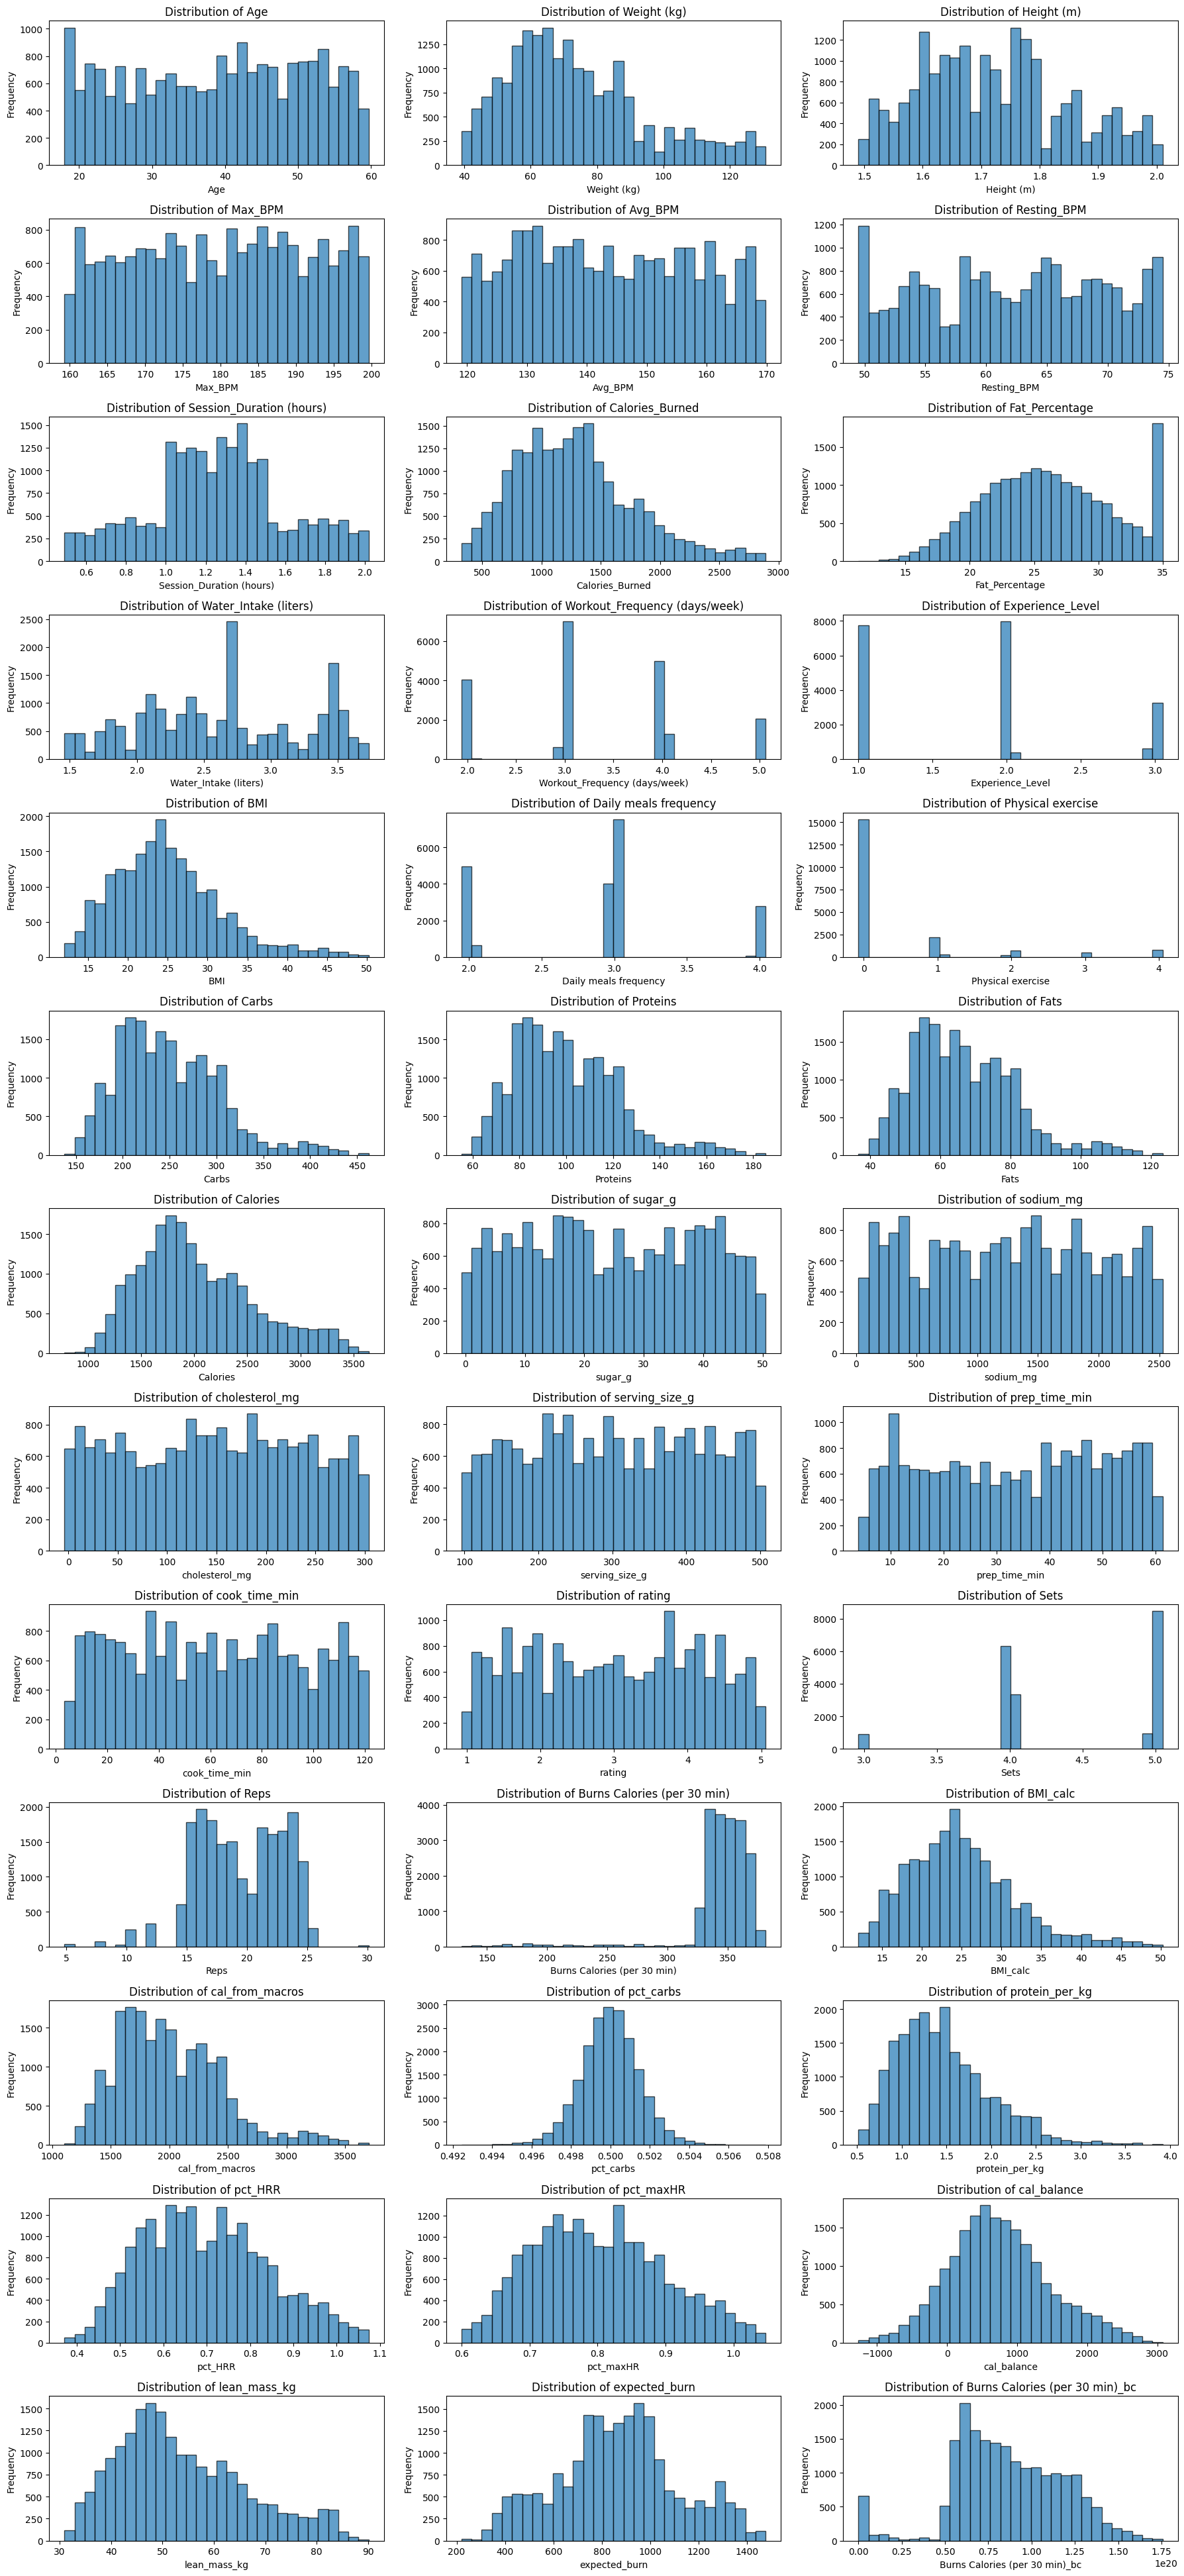

In [13]:
# distribusi variabel numerik dalam final_data
numerical_cols = final_data.select_dtypes(include=[np.number]).columns

fig, axes = plt.subplots(13, 3, figsize=(18, 39))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    if i < len(axes):
        axes[i].hist(final_data[col].dropna(), bins=30, alpha=0.7, edgecolor='black')
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

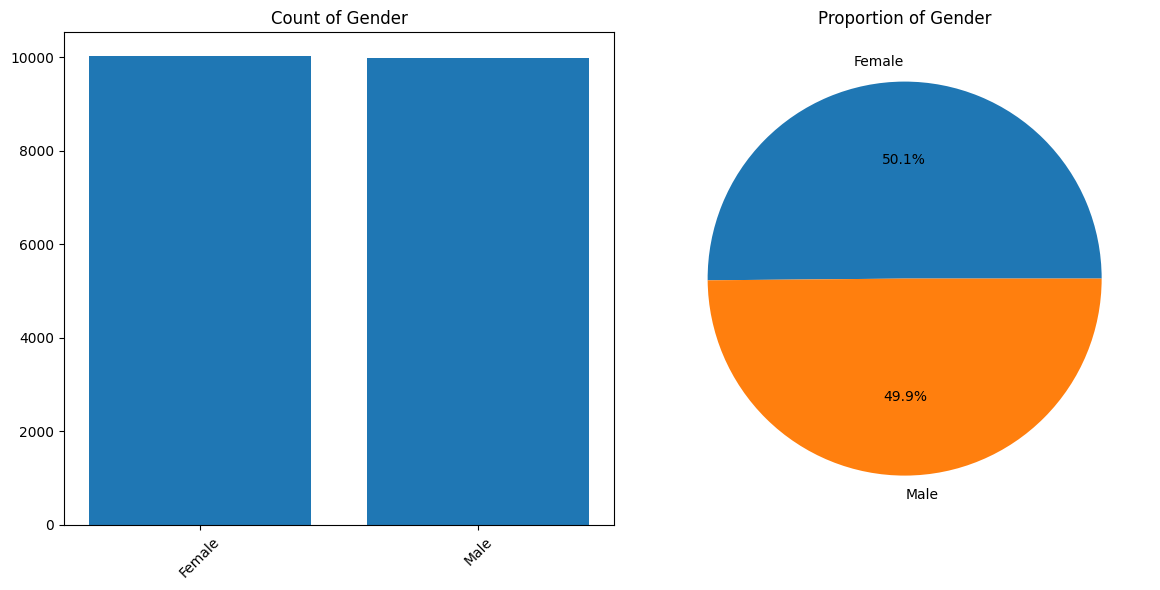

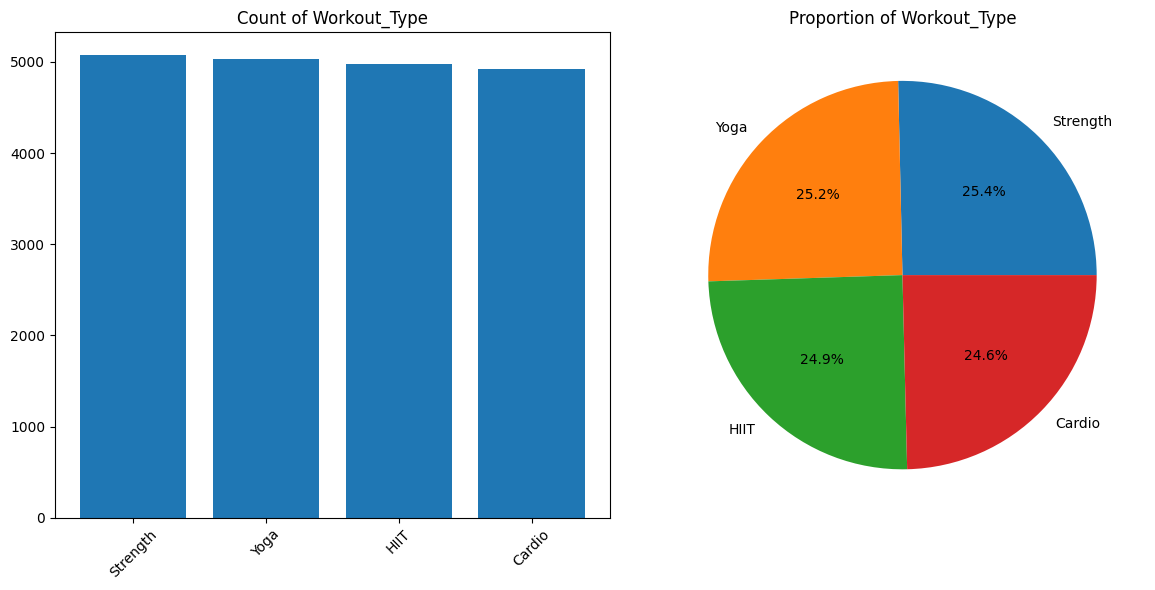

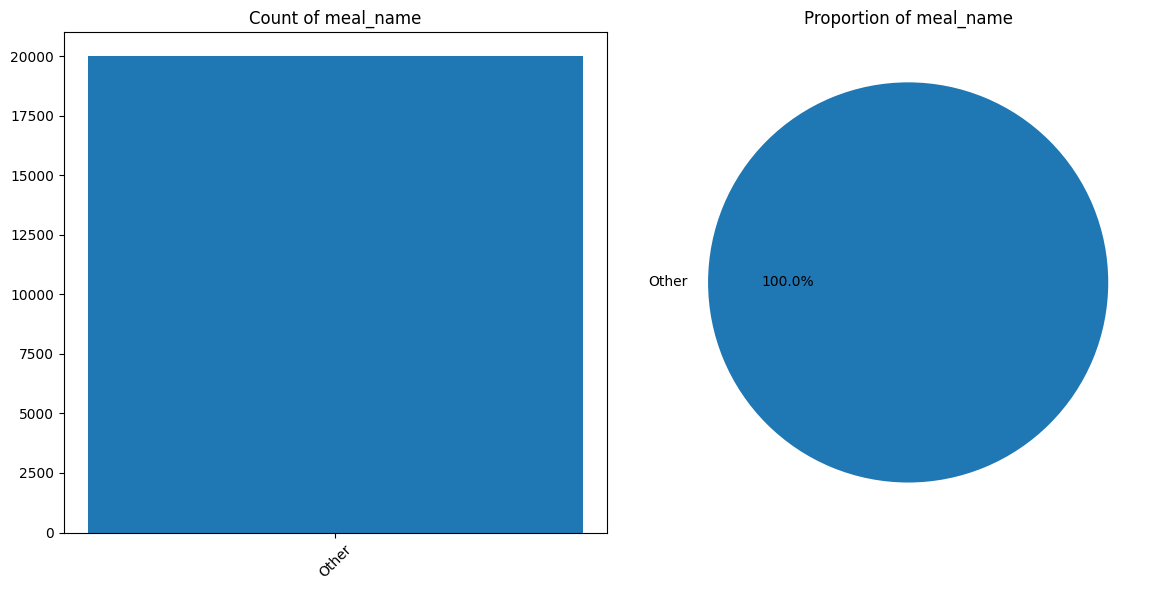

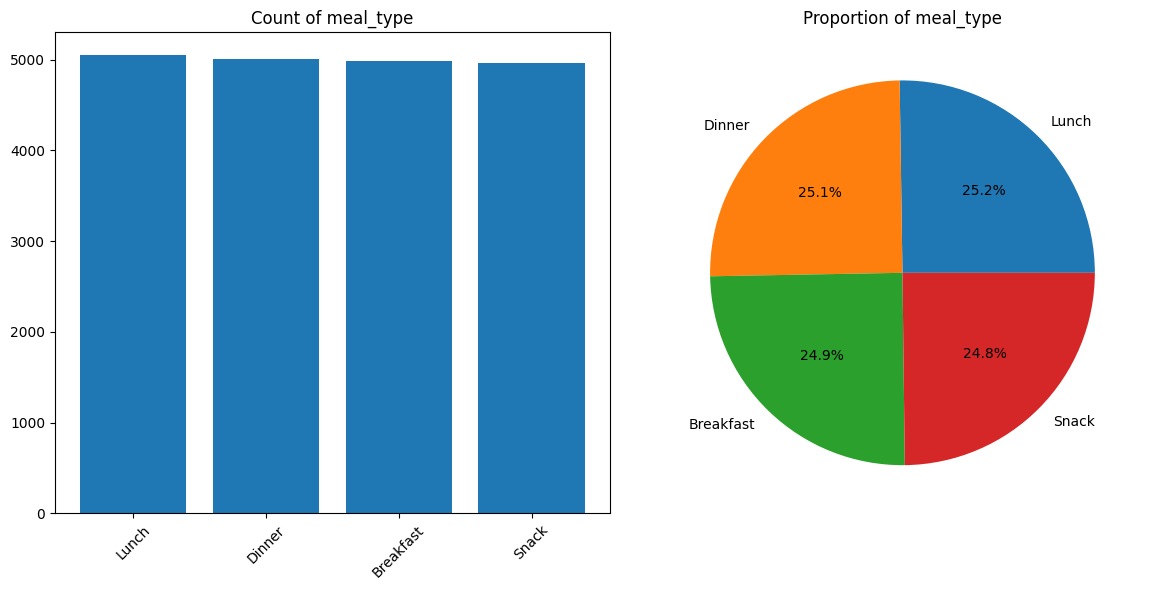

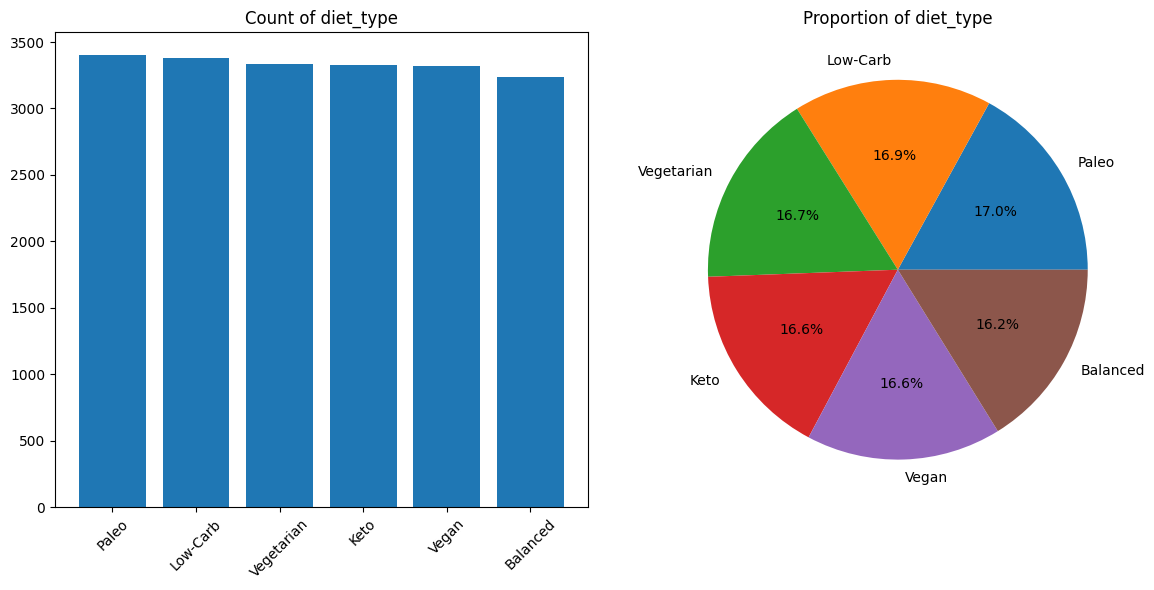

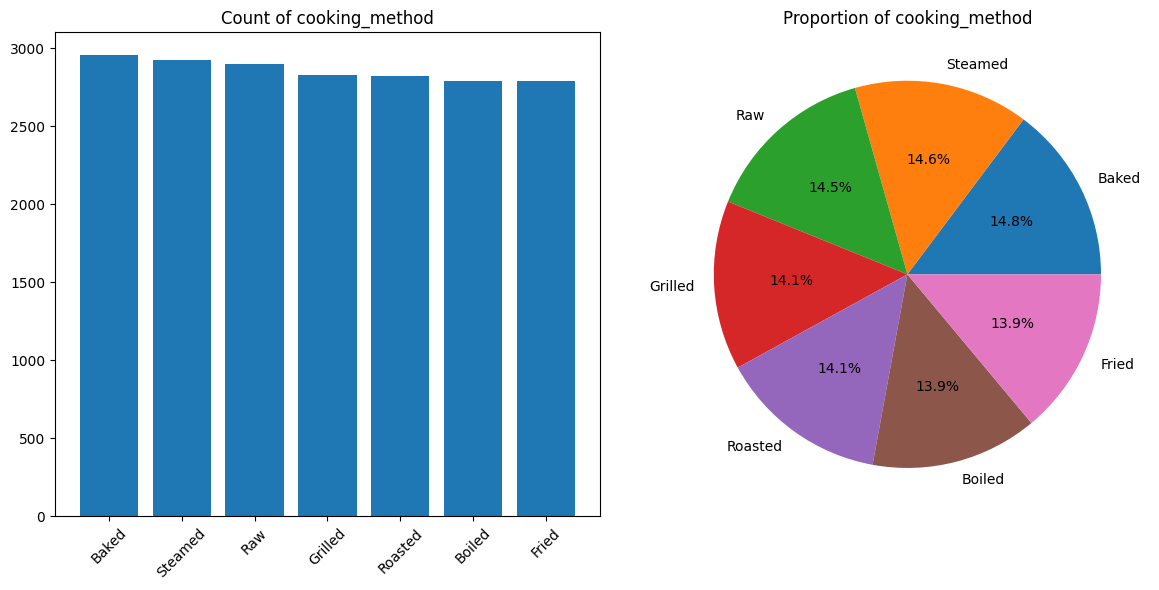

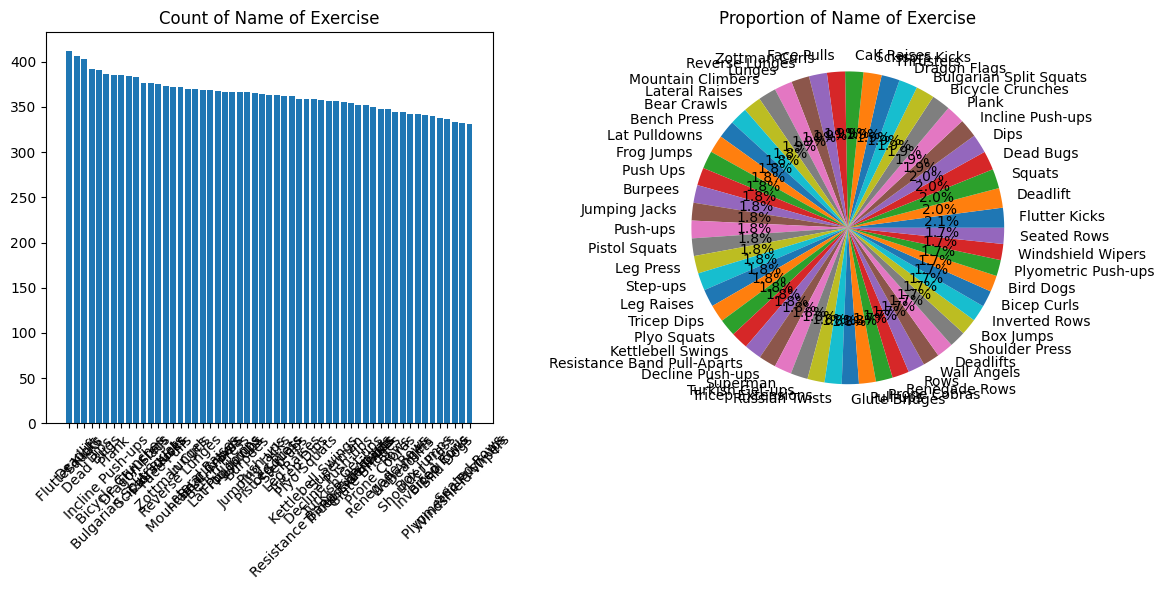

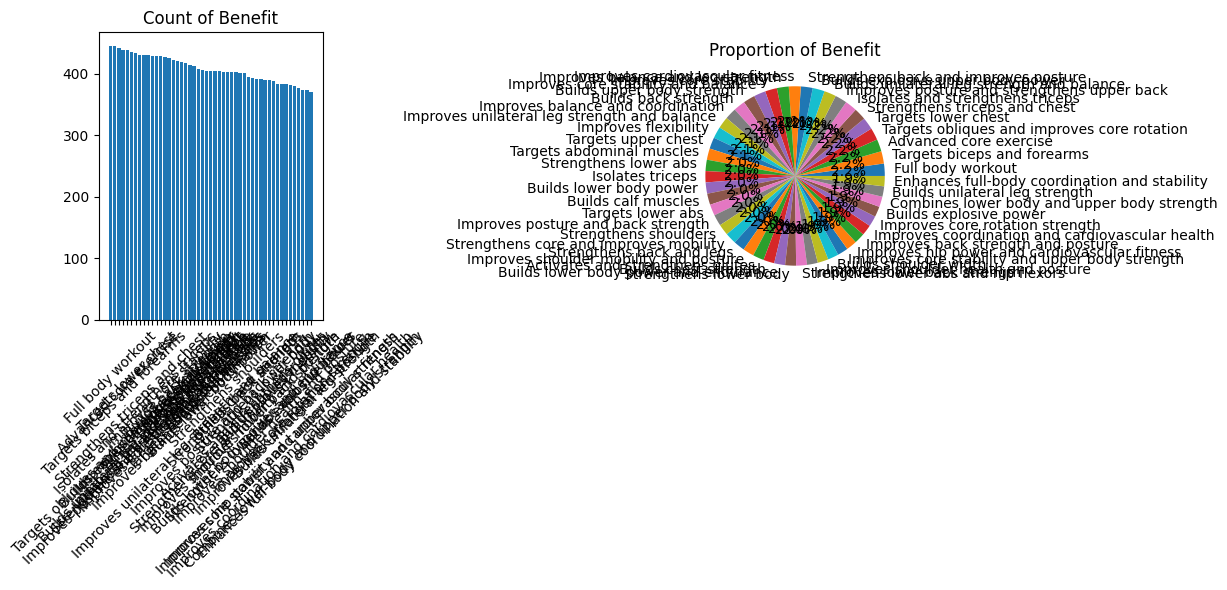

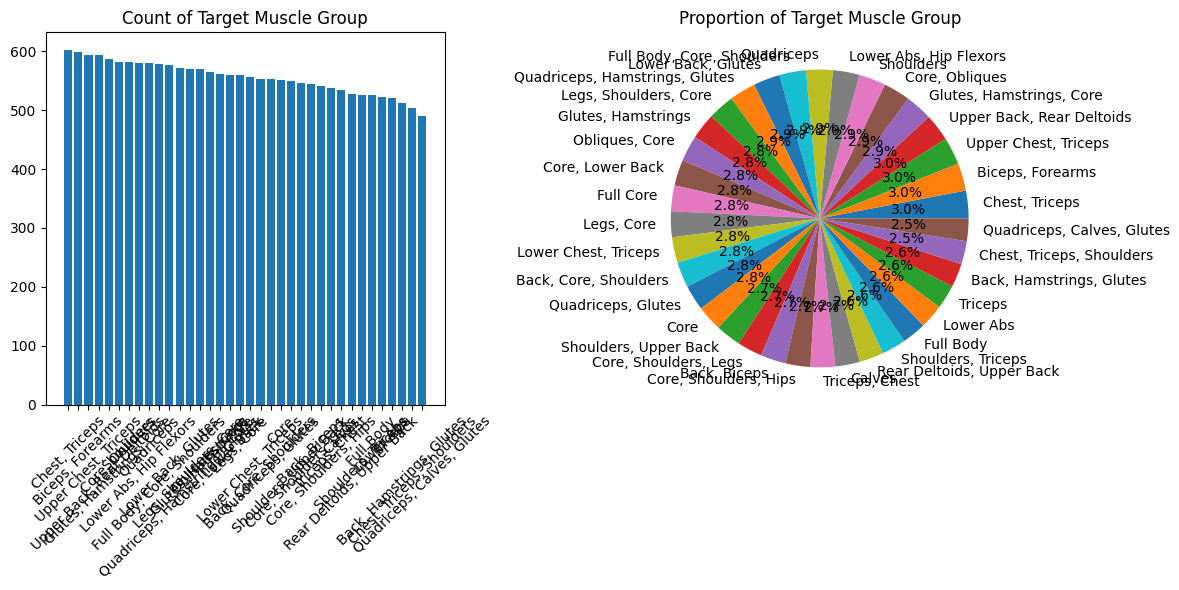

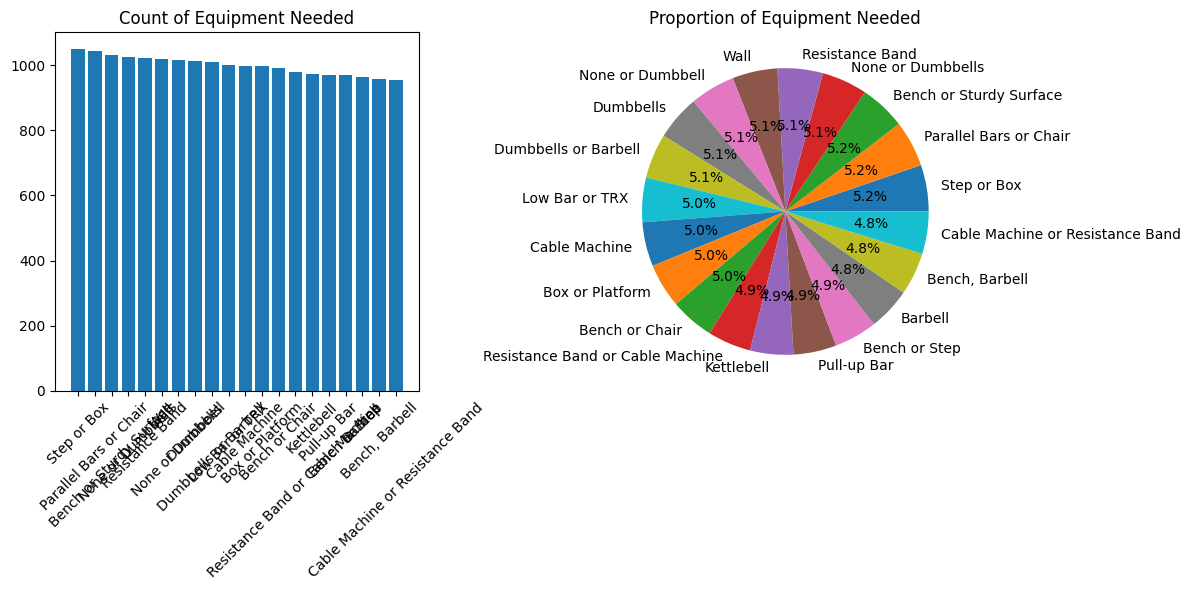

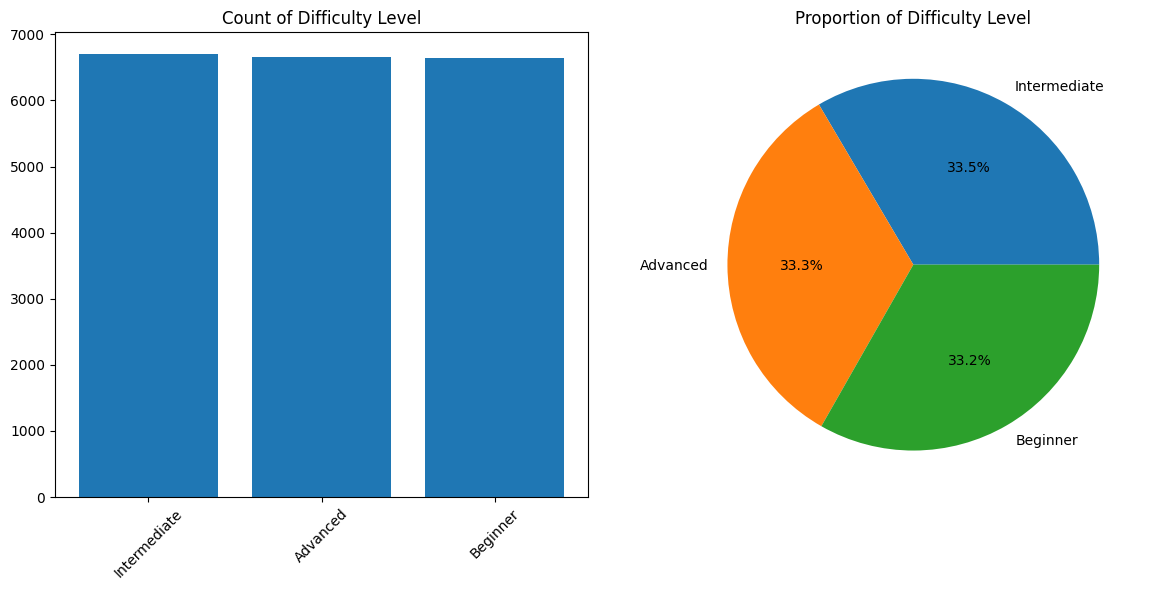

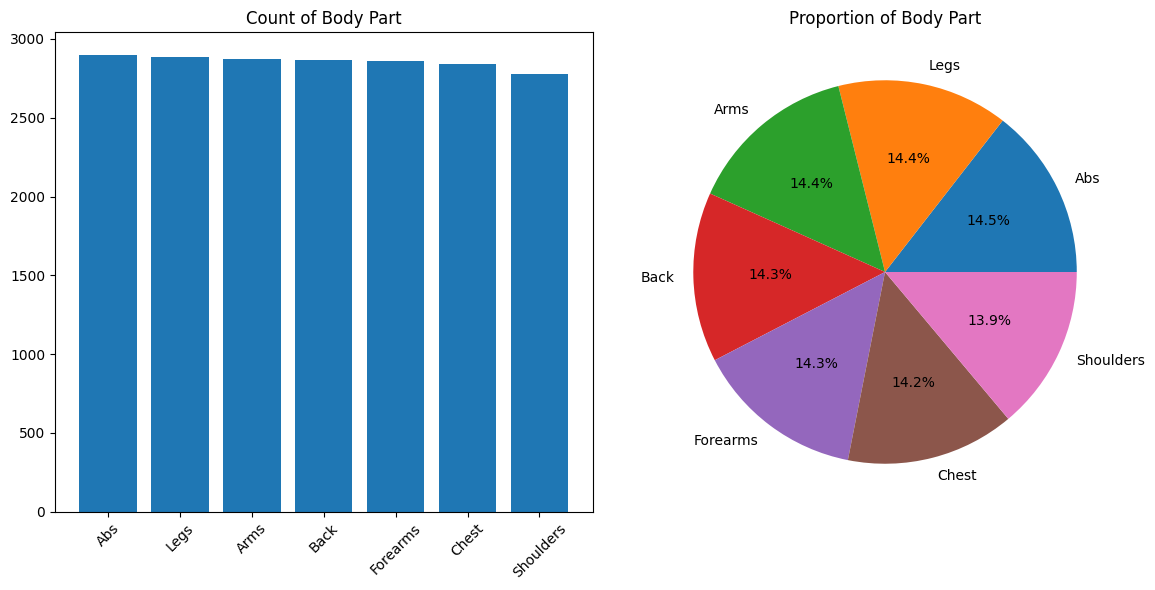

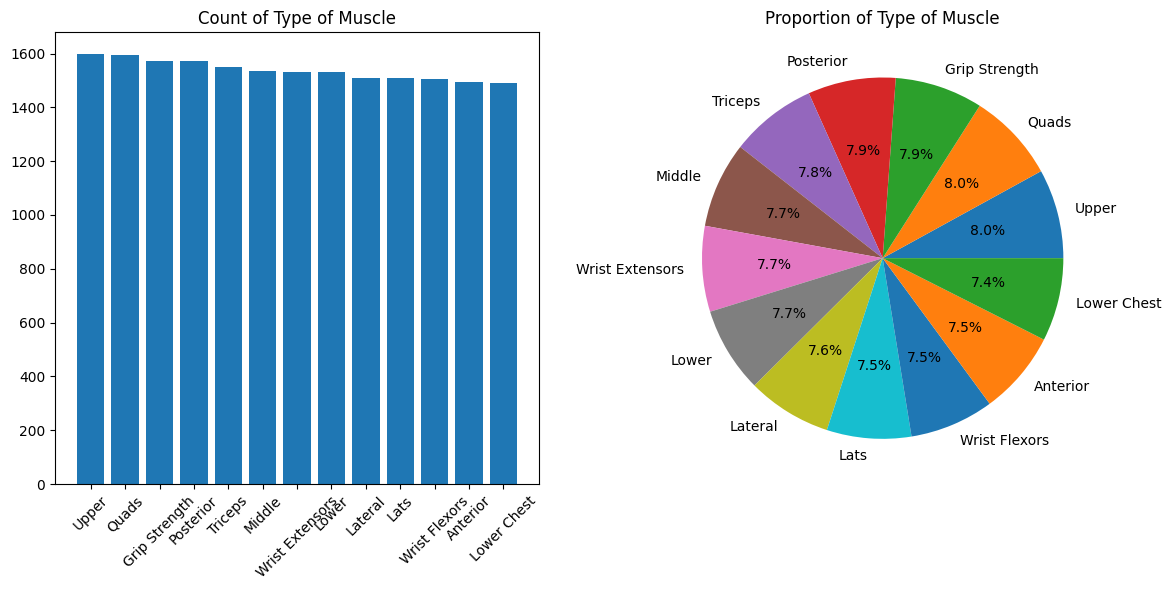

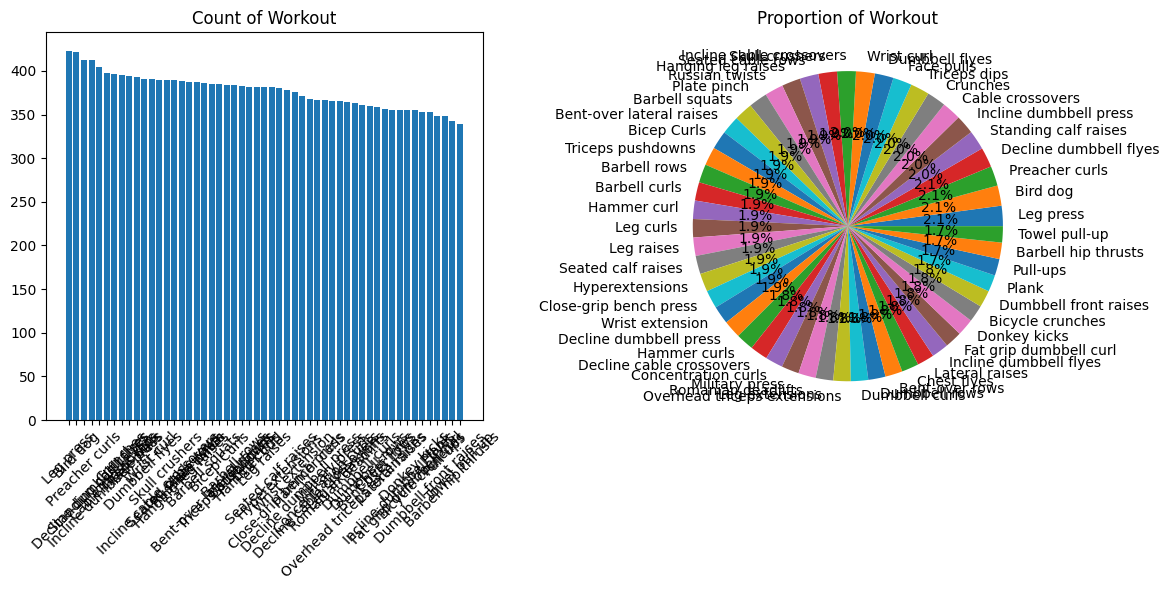

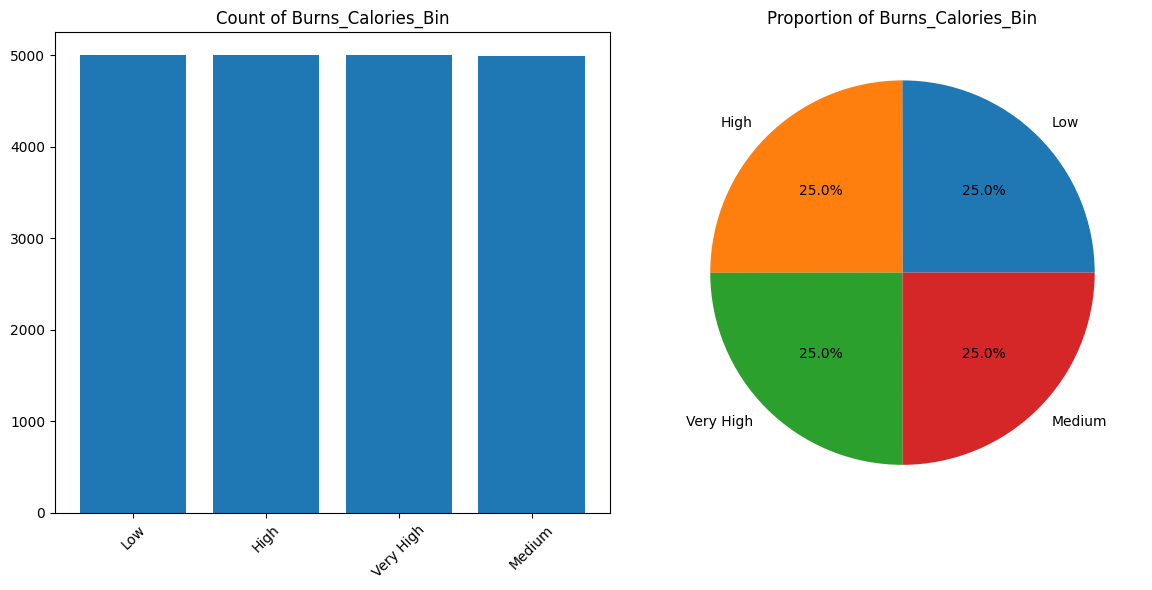

In [14]:
# Analisis variabel kategorikal
categorical_cols = final_data.select_dtypes(include=['object']).columns

for col in categorical_cols:
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    value_counts = final_data[col].value_counts()
    plt.bar(range(len(value_counts)), value_counts.values)
    plt.title(f'Count of {col}')
    plt.xticks(range(len(value_counts)), value_counts.index, rotation=45)
    
    plt.subplot(1, 2, 2)
    plt.pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%')
    plt.title(f'Proportion of {col}')
    
    plt.tight_layout()
    plt.show()

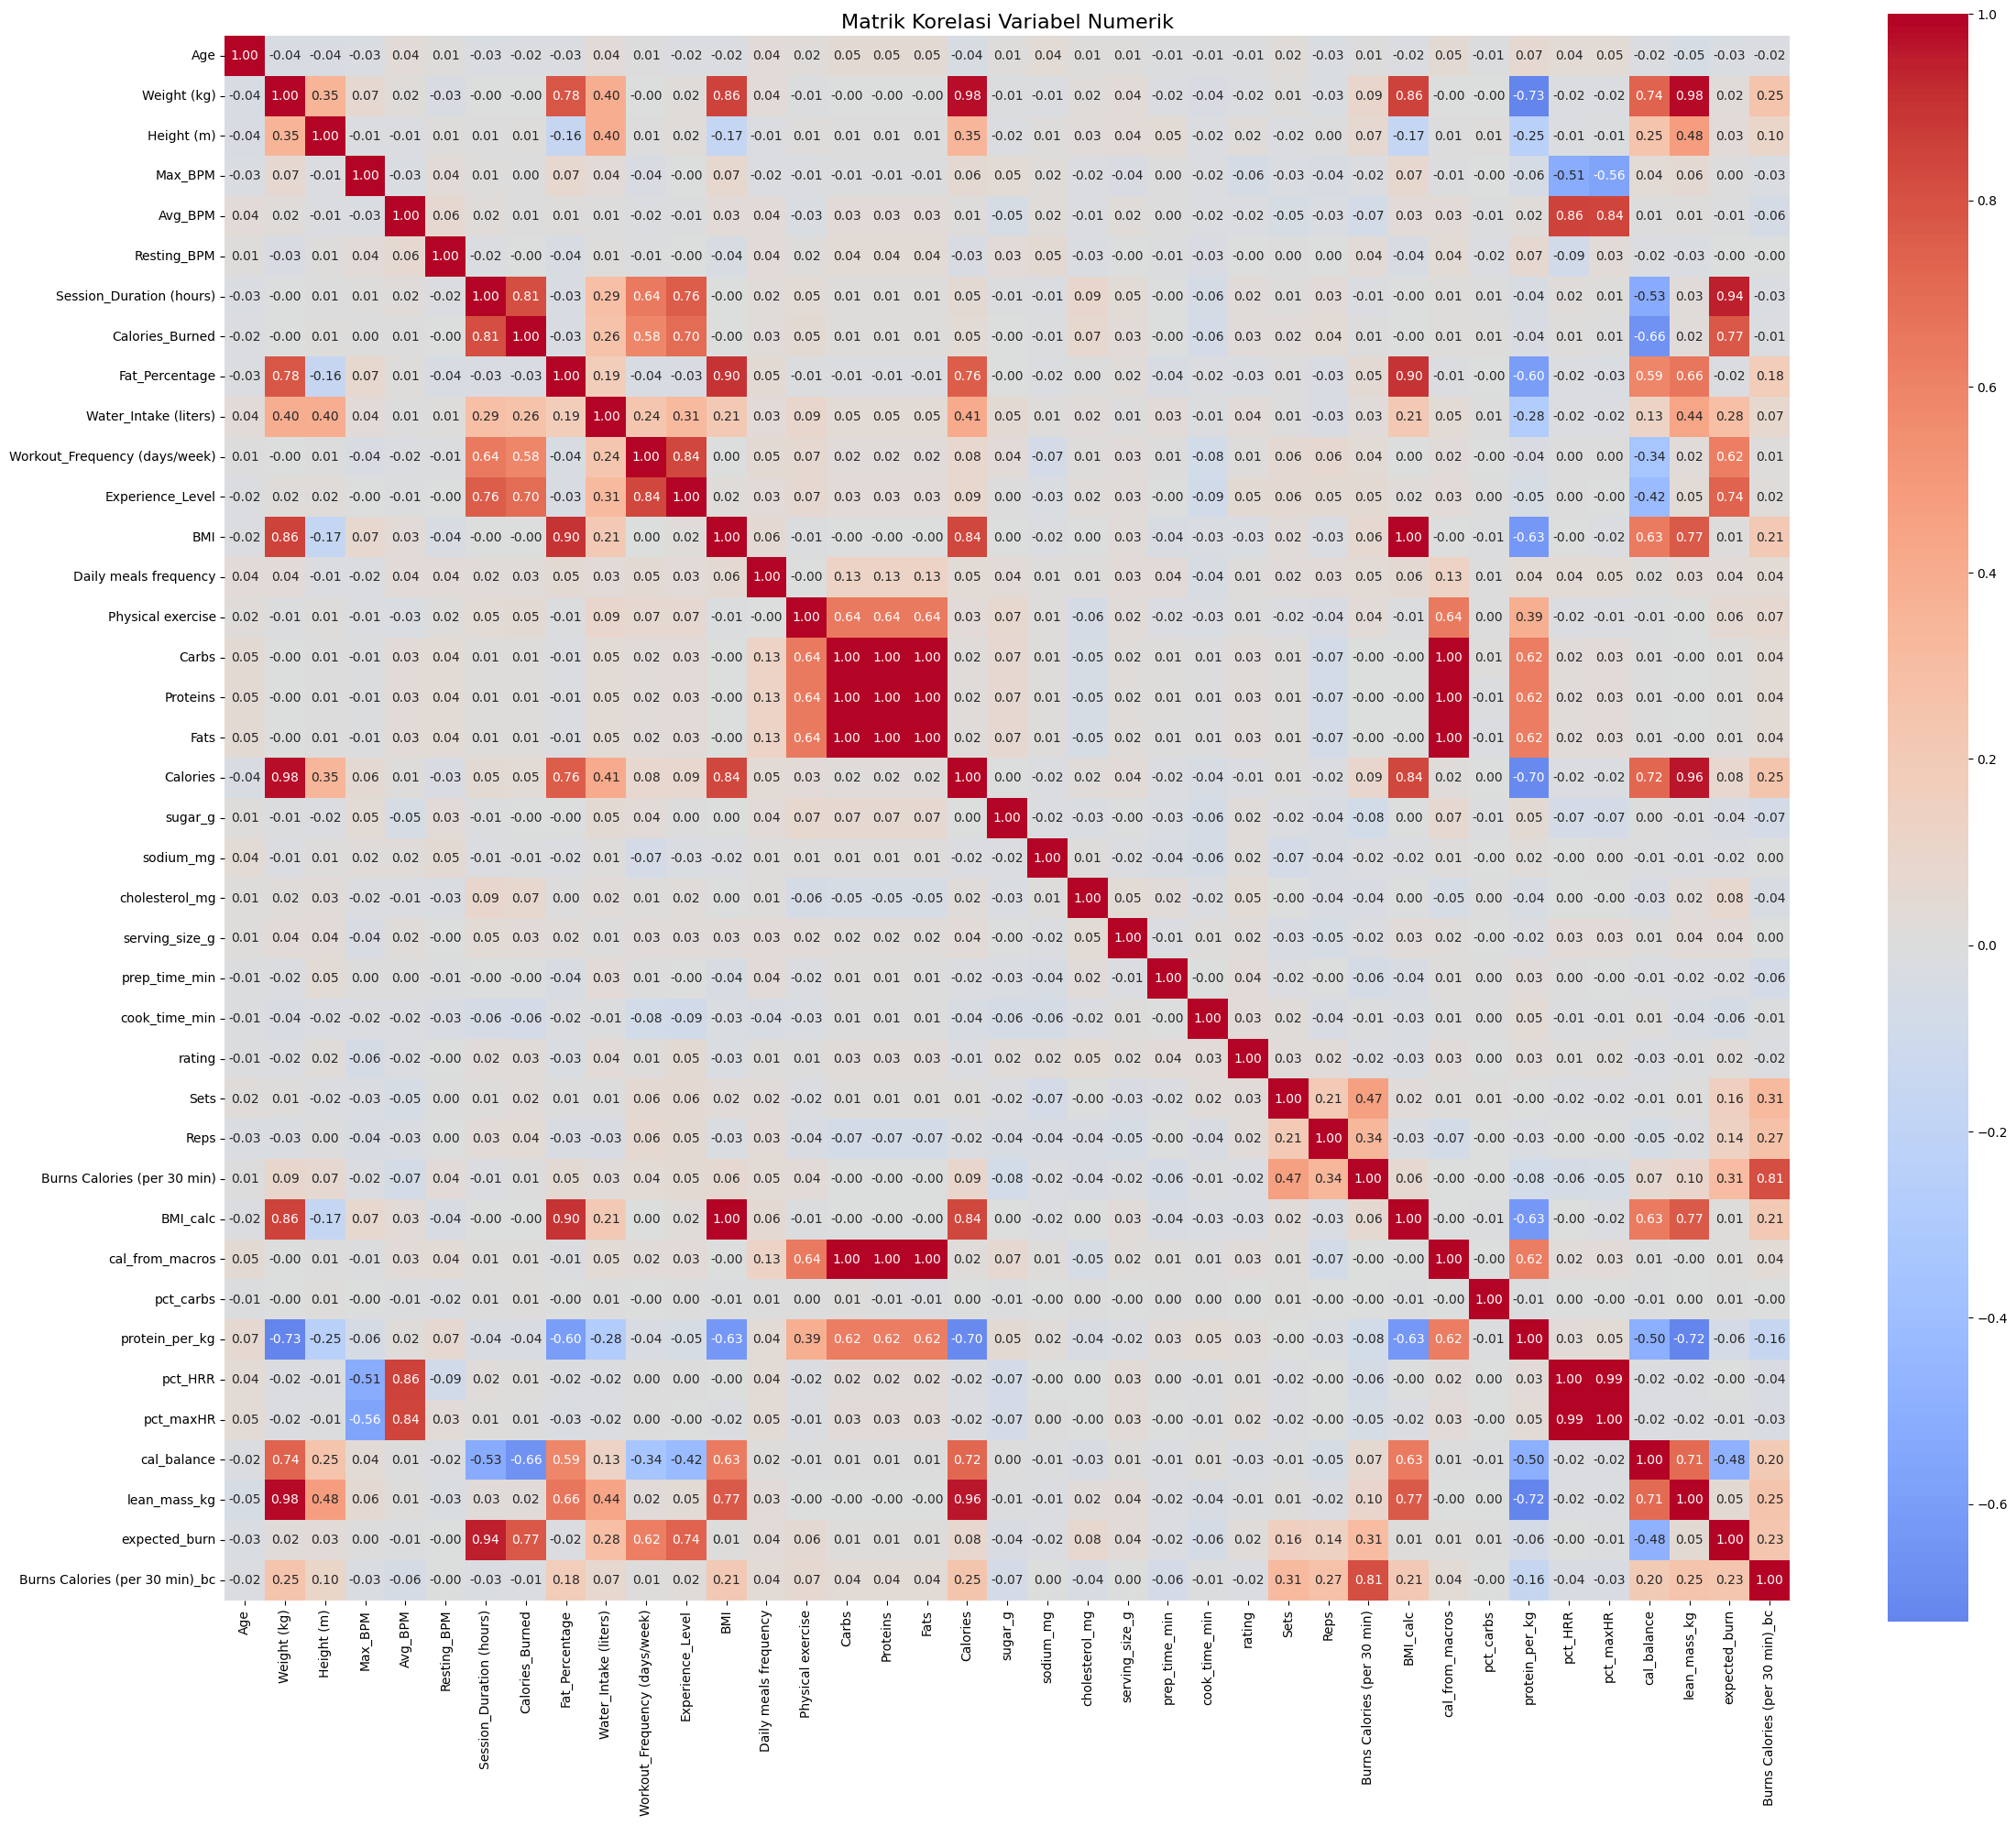

korelasi kuat antara variabel numerik:
Weight (kg)                    Fat_Percentage                    0.778875
                               BMI                               0.855599
                               Calories                          0.978273
                               BMI_calc                          0.855598
                               protein_per_kg                   -0.726714
                               cal_balance                       0.736698
                               lean_mass_kg                      0.981897
Avg_BPM                        pct_HRR                           0.856732
                               pct_maxHR                         0.841887
Session_Duration (hours)       Calories_Burned                   0.814368
                               Experience_Level                  0.758465
                               expected_burn                     0.944115
Calories_Burned                expected_burn                     0.773932

In [15]:
# Correlation matrix untuk variabel numerik
numerical_data = final_data.select_dtypes(include=[np.number])

plt.figure(figsize=(24, 20))
correlation_matrix = numerical_data.corr()
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f',
            square=True)
plt.title('Matrik Korelasi Variabel Numerik', fontsize=16)
plt.tight_layout()
plt.show()

# Strong correlations (> 0.7 or < -0.7)
strong_corr = correlation_matrix[(correlation_matrix > 0.7) | (correlation_matrix < -0.7)]
strong_corr = strong_corr.where(np.triu(np.ones_like(strong_corr, dtype=bool), k=1))
print("korelasi kuat antara variabel numerik:")
print(strong_corr.stack().dropna())

**Korelasi variabel kuat** terjadi ketika perubahan pada satu variabel secara signifikan berkaitan dengan perubahan pada variabel lain. Kekuatan korelasi diukur menggunakan koefisien korelasi, yang nilainya berkisar dari -1 hingga +1. Secara umum, nilai yang mendekati +1 atau -1 menunjukkan korelasi yang sangat kuat, sementara nilai yang mendekati 0 menunjukkan korelasi yang lemah. 

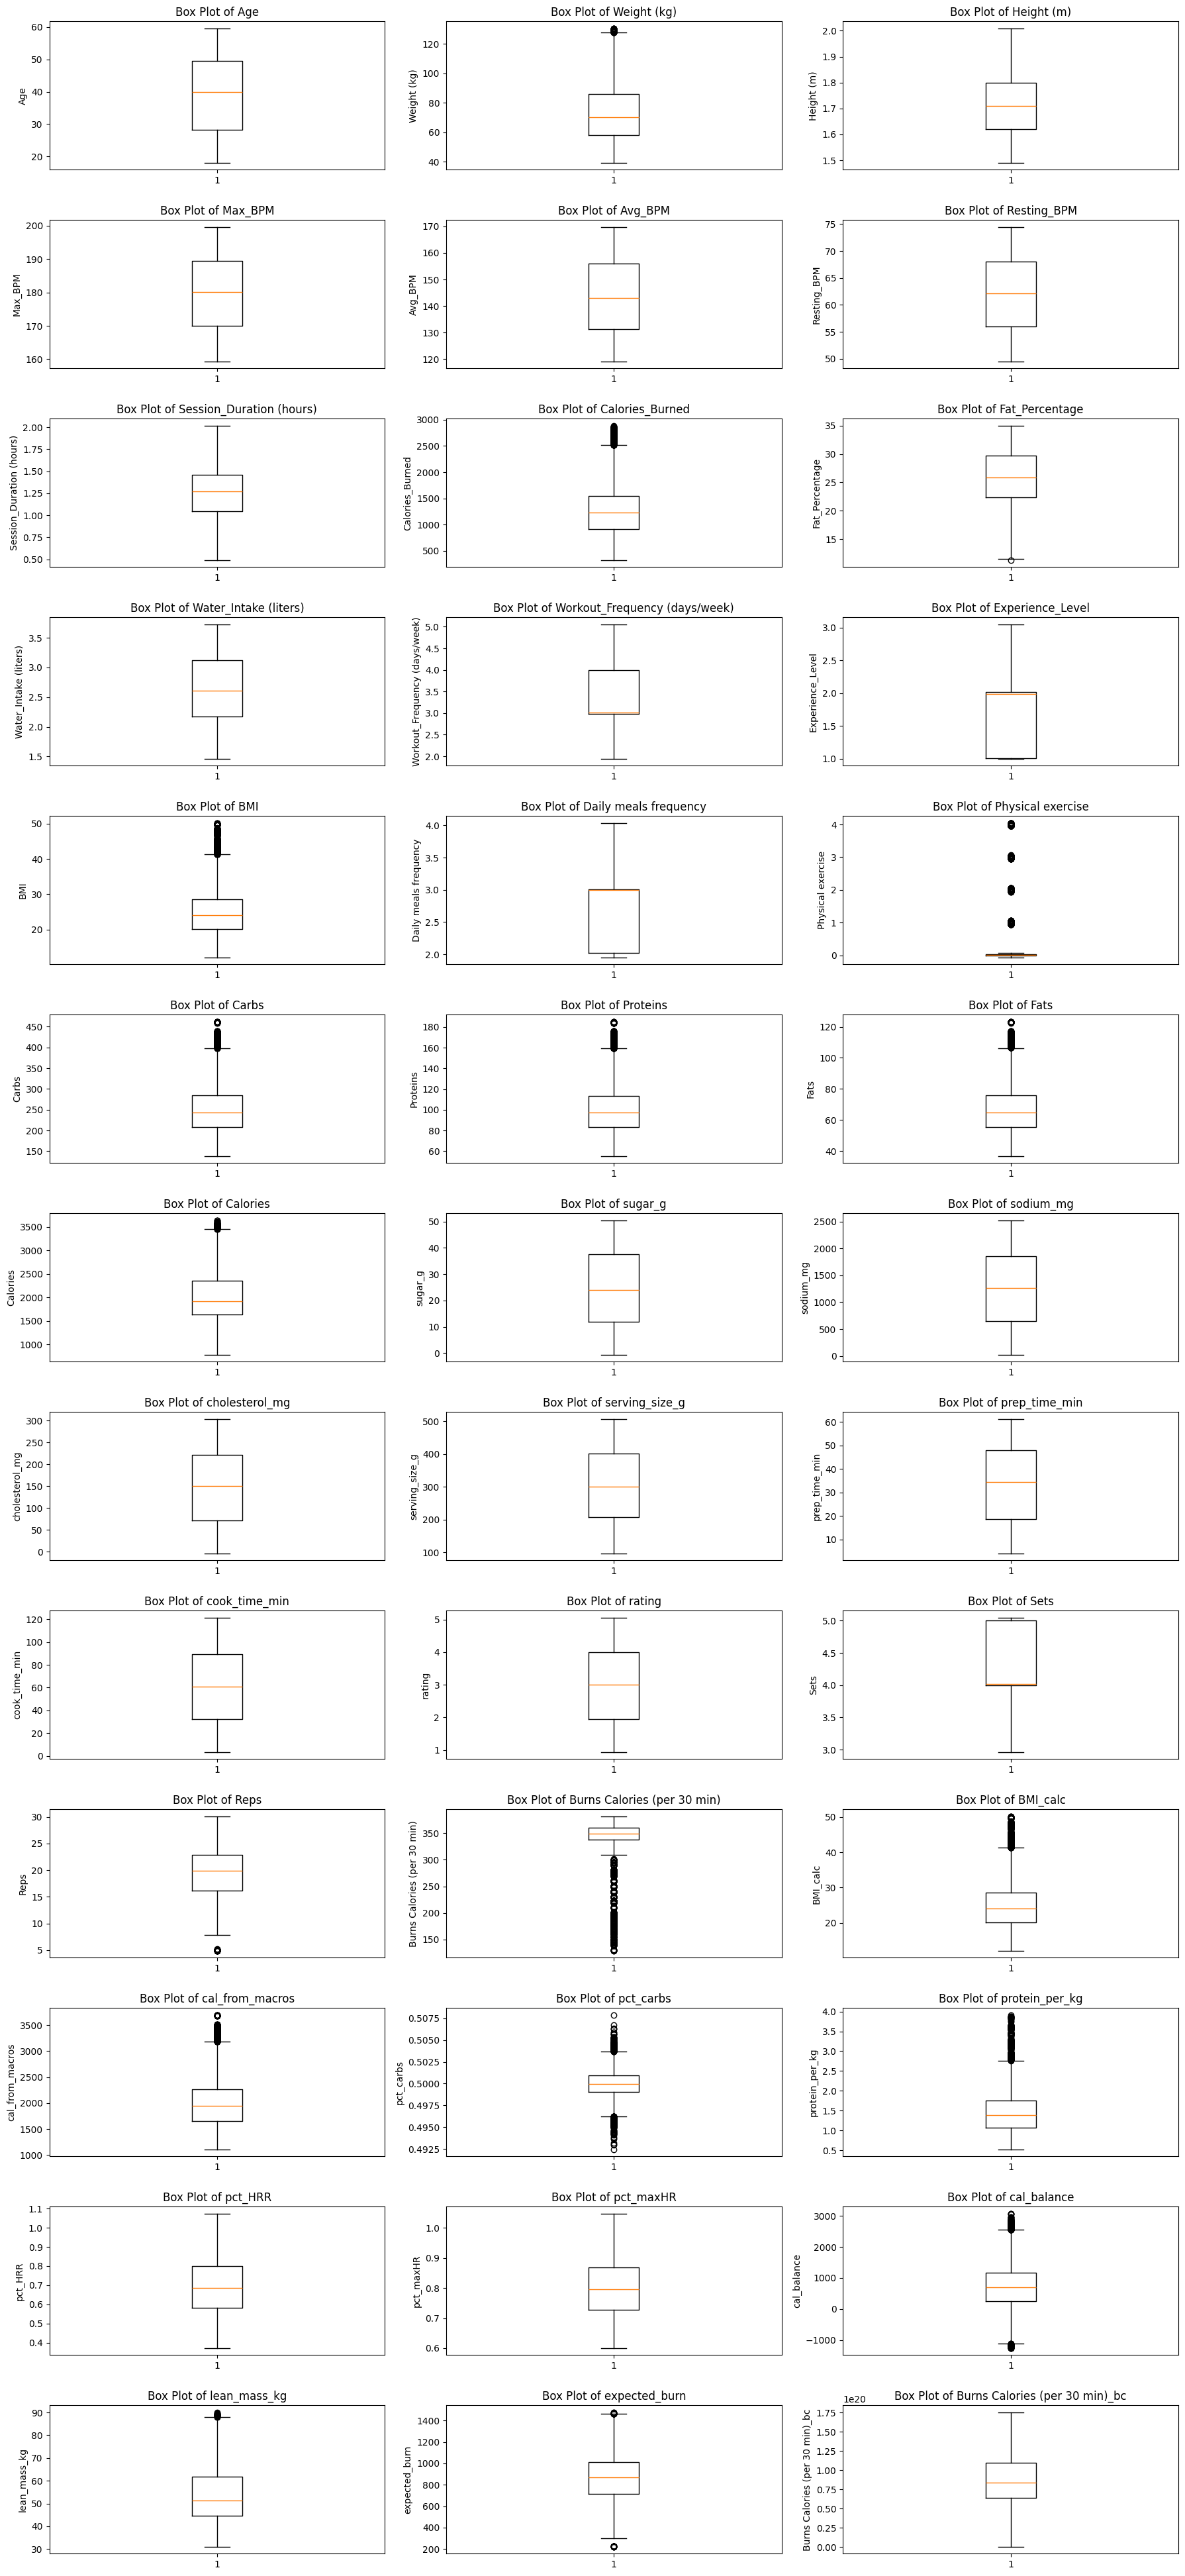

Age: 0 outliers detected (0.00%)
Weight (kg): 152 outliers detected (0.76%)
Height (m): 0 outliers detected (0.00%)
Max_BPM: 0 outliers detected (0.00%)
Avg_BPM: 0 outliers detected (0.00%)
Resting_BPM: 0 outliers detected (0.00%)
Session_Duration (hours): 0 outliers detected (0.00%)
Calories_Burned: 507 outliers detected (2.54%)
Fat_Percentage: 1 outliers detected (0.01%)
Water_Intake (liters): 0 outliers detected (0.00%)
Workout_Frequency (days/week): 0 outliers detected (0.00%)
Experience_Level: 0 outliers detected (0.00%)
BMI: 530 outliers detected (2.65%)
Daily meals frequency: 0 outliers detected (0.00%)
Physical exercise: 4695 outliers detected (23.47%)
Carbs: 405 outliers detected (2.02%)
Proteins: 403 outliers detected (2.02%)
Fats: 399 outliers detected (1.99%)
Calories: 102 outliers detected (0.51%)
sugar_g: 0 outliers detected (0.00%)
sodium_mg: 0 outliers detected (0.00%)
cholesterol_mg: 0 outliers detected (0.00%)
serving_size_g: 0 outliers detected (0.00%)
prep_time_min:

In [16]:
# Box plots untuk deteksi outliers
fig, axes = plt.subplots(13, 3, figsize=(18, 39))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    if i < len(axes):
        axes[i].boxplot(final_data[col].dropna())
        axes[i].set_title(f'Box Plot of {col}')
        axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

# Statistical outlier detection
for col in numerical_cols:
    Q1 = final_data[col].quantile(0.25)
    Q3 = final_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = final_data[(final_data[col] < lower_bound) | (final_data[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers detected ({len(outliers)/len(final_data)*100:.2f}%)")

Outlier adalah titik data yang berada di luar rentang normal atau sangat berbeda dari sebagian besar data lain dalam satu set data. Nilai-nilai ini bisa sangat tinggi atau sangat rendah dibandingkan data lainnya dan dapat disebabkan oleh kesalahan pengukuran atau kejadian yang memang unik. Penting untuk diperhatikan karena outlier dapat memengaruhi hasil analisis, meskipun terkadang juga bisa berisi informasi yang penting. 

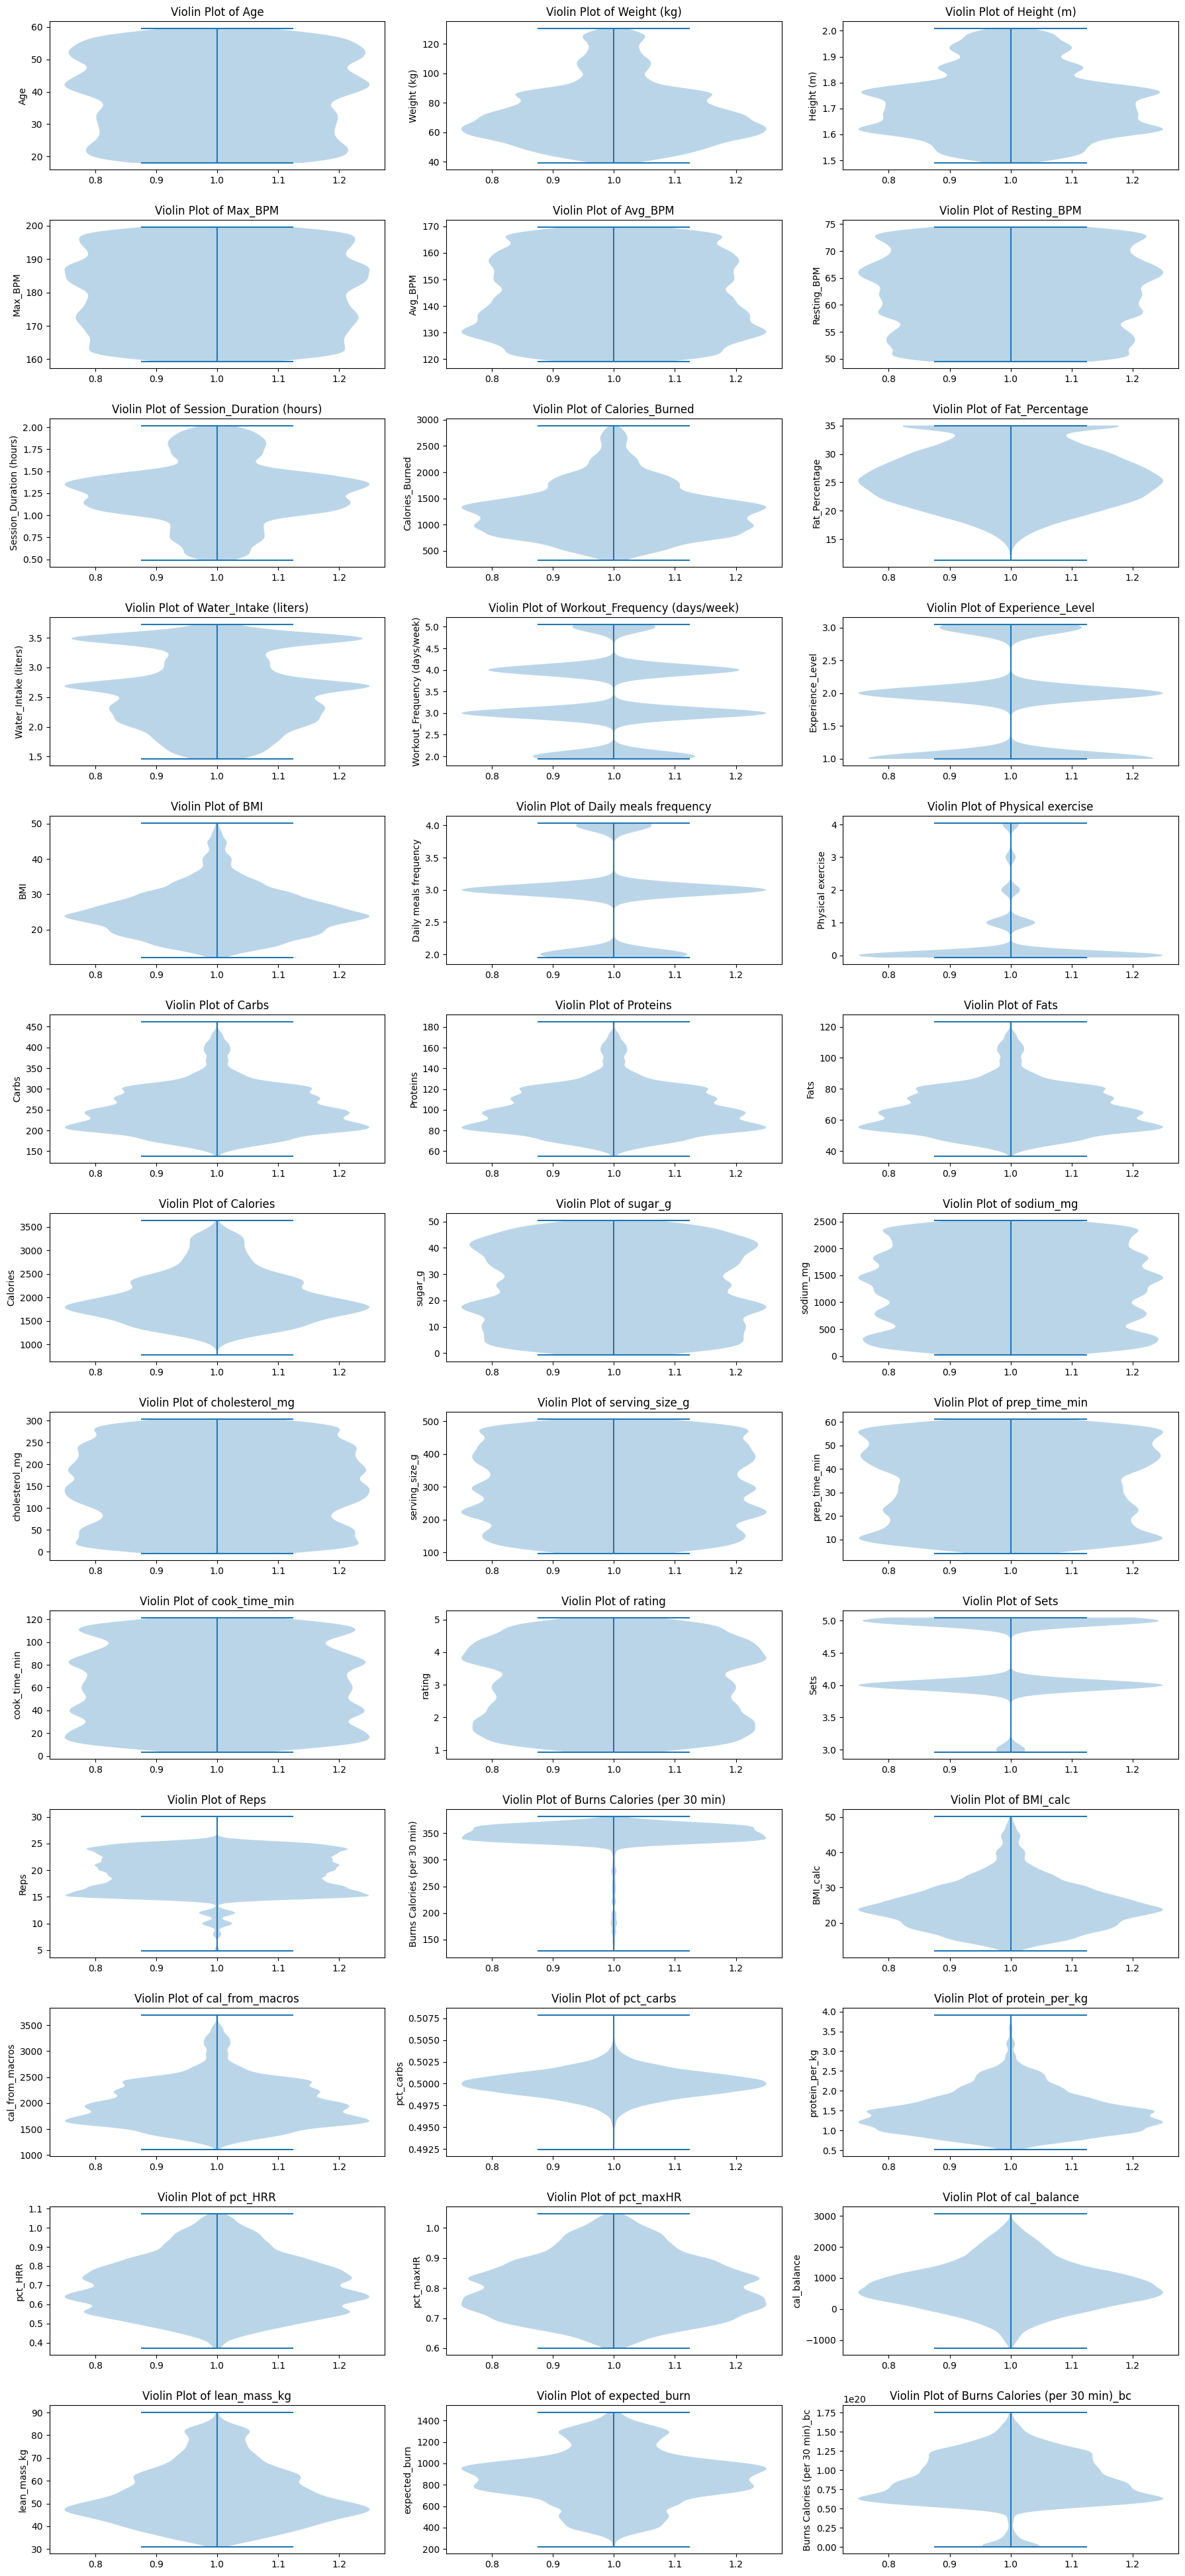

In [17]:
# Pair plot untuk melihat relationship antar variabel
if len(numerical_cols) <= 6:  # Untuk performa yang baik
    sns.pairplot(final_data[numerical_cols].sample(1000) if len(final_data) > 1000 else final_data[numerical_cols])
    plt.suptitle('Pair Plot of Numerical Variables', y=1.02)
    plt.show()

# Violin plots
fig, axes = plt.subplots(13, 3, figsize=(18, 39))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    if i < len(axes):
        axes[i].violinplot([final_data[col].dropna()])
        axes[i].set_title(f'Violin Plot of {col}')
        axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

In [18]:
# Data quality report
print("=== DATA QUALITY REPORT ===")
print(f"Total rows: {len(final_data)}")
print(f"Total columns: {len(final_data.columns)}")
print(f"Duplicate rows: {final_data.duplicated().sum()}")
print(f"Completely empty rows: {final_data.isnull().all(axis=1).sum()}")

# Missing data pattern
missing_pattern = final_data.isnull().sum()
missing_pattern = missing_pattern[missing_pattern > 0].sort_values(ascending=False)

if len(missing_pattern) > 0:
    plt.figure(figsize=(12, 6))
    missing_pattern.plot(kind='bar')
    plt.title('Missing Values by Column')
    plt.ylabel('Count of Missing Values')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

=== DATA QUALITY REPORT ===
Total rows: 20000
Total columns: 54
Duplicate rows: 0
Completely empty rows: 0


# Modelling

## Clustering

In [19]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [20]:
# K-Means Clustering untuk segmentasi lifestyle
scaler = StandardScaler()
numerical_features = final_data.select_dtypes(include=[np.number])
print(numerical_features.head())
scaled_features = scaler.fit_transform(numerical_features)
scaled_features

     Age  Weight (kg)  Height (m)  Max_BPM  Avg_BPM  Resting_BPM  \
0  34.91        65.27        1.62   188.58   157.65        69.05   
1  23.37        56.41        1.55   179.43   131.75        73.18   
2  33.20        58.98        1.67   175.04   123.95        54.96   
3  38.69        93.78        1.70   191.21   155.10        50.07   
4  45.09        52.42        1.88   193.58   152.88        70.84   

   Session_Duration (hours)  Calories_Burned  Fat_Percentage  \
0                      1.00          1080.90       26.800377   
1                      1.37          1809.91       27.655021   
2                      0.91           802.26       24.320821   
3                      1.10          1450.79       32.813572   
4                      1.08          1166.40       17.307319   

   Water_Intake (liters)  ...   BMI_calc  cal_from_macros  pct_carbs  \
0                   1.50  ...  24.870447          2139.59   0.500432   
1                   1.90  ...  23.479709          1711.65   0.

array([[-0.32535605, -0.40754939, -0.81157054, ..., -0.48077968,
        -0.72386933, -0.42889028],
       [-1.27795104, -0.82601713, -1.3626231 , ..., -1.03825711,
         0.44850672,  0.49202692],
       [-0.46651181, -0.70463315, -0.41796156, ..., -0.73215644,
        -0.84625078,  0.67686323],
       ...,
       [ 0.94587123, -1.30824689, -0.41796156, ..., -1.46943896,
         0.36596295,  0.14682834],
       [ 1.11509304, -1.39798602, -0.81157054, ..., -1.43195002,
         0.24788415, -1.05875418],
       [-0.76698371, -0.72116404, -0.89029233, ..., -0.75874723,
        -0.10086787,  0.03460998]], shape=(20000, 39))

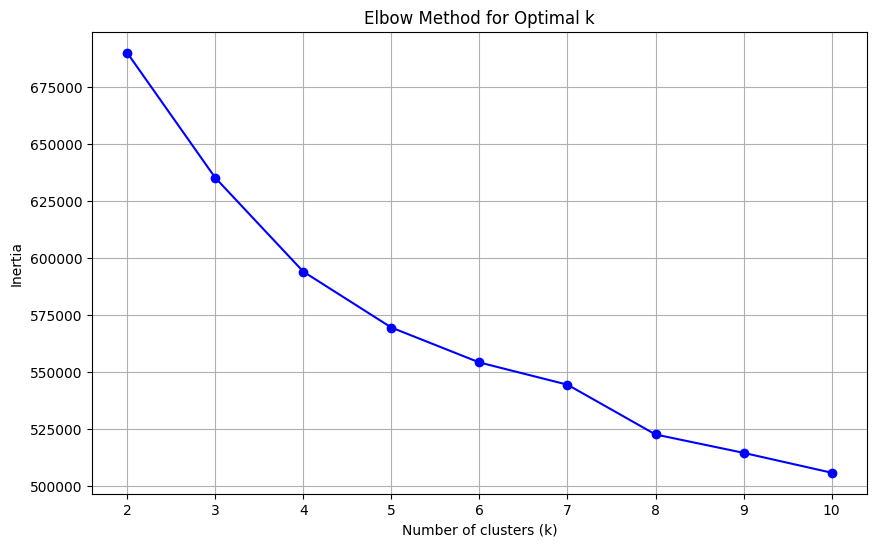

In [21]:
inertia = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, 'bo-')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid()
plt.show()

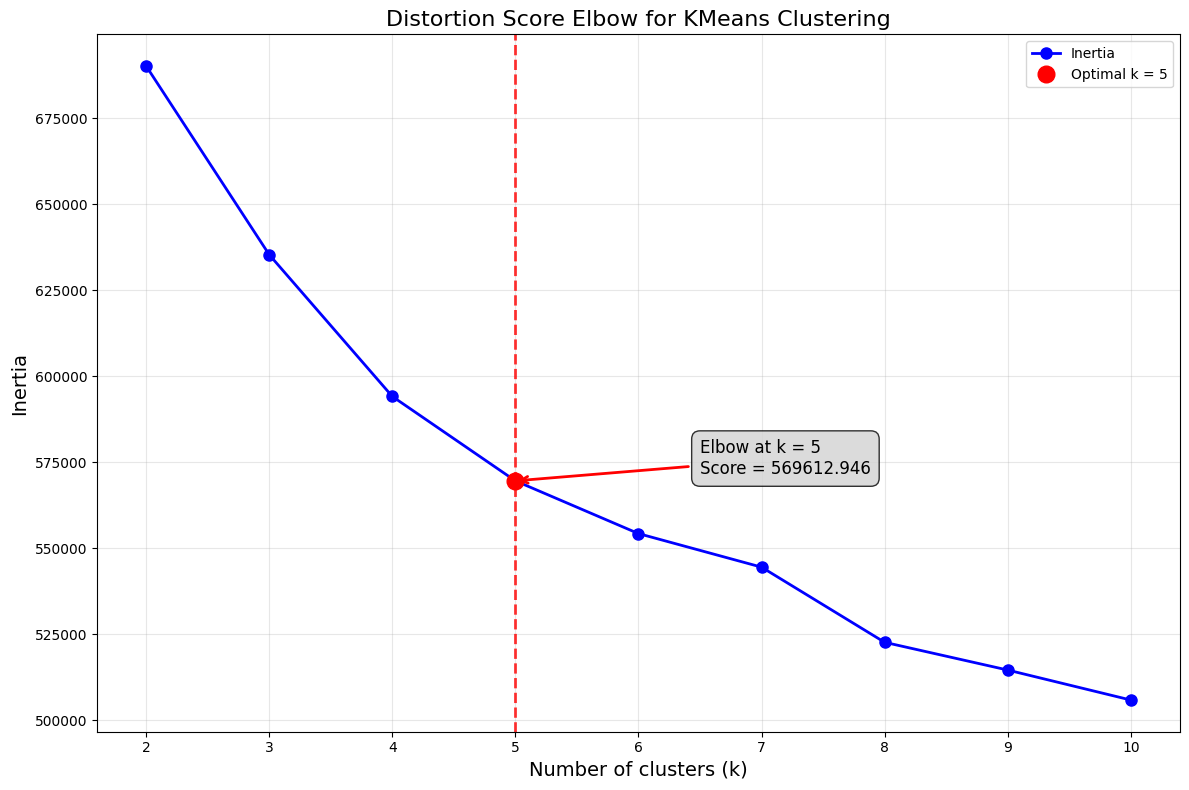

Optimal number of clusters: 5
Inertia at optimal k: 569612.946


In [22]:
# Hitung inertia
inertia = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

# Hitung second derivative untuk mendeteksi elbow
def find_elbow(k_range, inertia):
    # Hitung first derivative
    first_derivative = np.diff(inertia)
    # Hitung second derivative
    second_derivative = np.diff(first_derivative)
    # Cari titik dengan perubahan terbesar
    elbow_index = np.argmax(second_derivative) + 2  # +2 karena kita kehilangan 2 point dari diff
    return k_range[elbow_index]

optimal_k = find_elbow(list(k_range), inertia)

# Plot dengan marking pada elbow point
plt.figure(figsize=(12, 8))
plt.plot(k_range, inertia, 'bo-', linewidth=2, markersize=8, label='Inertia')

# Tandai titik optimal
plt.axvline(x=optimal_k, color='red', linestyle='--', linewidth=2, alpha=0.8)
plt.plot(optimal_k, inertia[optimal_k-2], 'ro', markersize=12, label=f'Optimal k = {optimal_k}')

# Tambahkan annotation
plt.annotate(f'Elbow at k = {optimal_k}\nScore = {inertia[optimal_k-2]:.3f}', 
             xy=(optimal_k, inertia[optimal_k-2]), 
             xytext=(optimal_k + 1.5, inertia[optimal_k-2] + 2000),
             arrowprops=dict(arrowstyle='->', color='red', linewidth=2),
             fontsize=12, 
             bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8))

plt.title('Distortion Score Elbow for KMeans Clustering', fontsize=16)
plt.xlabel('Number of clusters (k)', fontsize=14)
plt.ylabel('Inertia', fontsize=14)
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Optimal number of clusters: {optimal_k}")
print(f"Inertia at optimal k: {inertia[optimal_k-2]:.3f}")

In [23]:
# Implementasi K-Means dengan k optimal
optimal_k = 5  # Berdasarkan hasil elbow method
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans_final.fit_predict(scaled_features)

In [26]:
# Tambahkan label cluster ke dataframe original
final_data_clustered = final_data.copy()
final_data_clustered['Cluster'] = cluster_labels

print(f"Distribusi Cluster:")
print(final_data_clustered['Cluster'].value_counts().sort_index())

# Analisis karakteristik setiap cluster
print("\n=== ANALISIS KARAKTERISTIK CLUSTER ===")
cluster_summary = final_data_clustered.groupby('Cluster')[numerical_features.columns].mean()
cluster_summary

Distribusi Cluster:
Cluster
0    3814
1    3493
2    5845
3    4609
4    2239
Name: count, dtype: int64

=== ANALISIS KARAKTERISTIK CLUSTER ===


,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),...,BMI_calc,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc
Cluster,,,,,,,,,,,,,,,,,,,,,
0,38.030147,107.893655,1.784693,181.789276,145.108841,61.459612,1.130194,1096.212824,32.416240,2.920220,...,34.227799,1956.915008,0.499952,0.920969,0.701350,0.801761,1760.037307,72.739048,789.148813,1.007122e+20
1,38.037037,75.109628,1.737375,180.553891,142.645302,62.014457,1.736656,1942.626874,25.923525,3.148371,...,24.976164,1851.232677,0.500008,1.265891,0.686404,0.793191,163.846358,55.442538,1200.599164,8.519227e+19
2,38.452250,64.805478,1.686578,182.497969,135.416821,61.725617,1.117350,1086.596200,25.031893,2.336217,...,22.993096,1766.960595,0.499996,1.401660,0.611391,0.743511,691.544775,48.328304,765.580920,8.220283e+19
3,39.789243,58.024585,1.705437,174.382350,155.256863,62.923311,1.171779,1154.428295,22.702817,2.333693,...,20.138802,2045.707681,0.499971,1.829250,0.833322,0.892916,449.008893,44.558165,790.473328,7.831284e+19
4,40.632738,70.517628,1.727552,180.145654,140.817669,63.462720,1.286552,1323.682818,25.409181,2.681353,...,23.864256,2804.537990,0.499988,2.074492,0.666900,0.784413,665.259120,52.162858,895.680154,9.077621e+19


=== KOORDINAT CENTROID SETIAP CLUSTER ===
     Age  Weight (kg)  Height (m)  Max_BPM  Avg_BPM  Resting_BPM  \
0  38.03       107.90        1.78   181.79   145.11        61.46   
1  38.04        75.11        1.74   180.55   142.65        62.01   
2  38.46        64.80        1.69   182.51   135.41        61.72   
3  39.80        58.04        1.71   174.38   155.26        62.92   
4  40.62        70.51        1.73   180.13   140.81        63.47   

   Session_Duration (hours)  Calories_Burned  Fat_Percentage  \
0                      1.13          1096.22           32.42   
1                      1.74          1942.63           25.92   
2                      1.12          1086.82           25.03   
3                      1.17          1154.08           22.71   
4                      1.29          1323.51           25.41   

   Water_Intake (liters)  ...  BMI_calc  cal_from_macros  pct_carbs  \
0                   2.92  ...     34.23          1956.89        0.5   
1                   3.

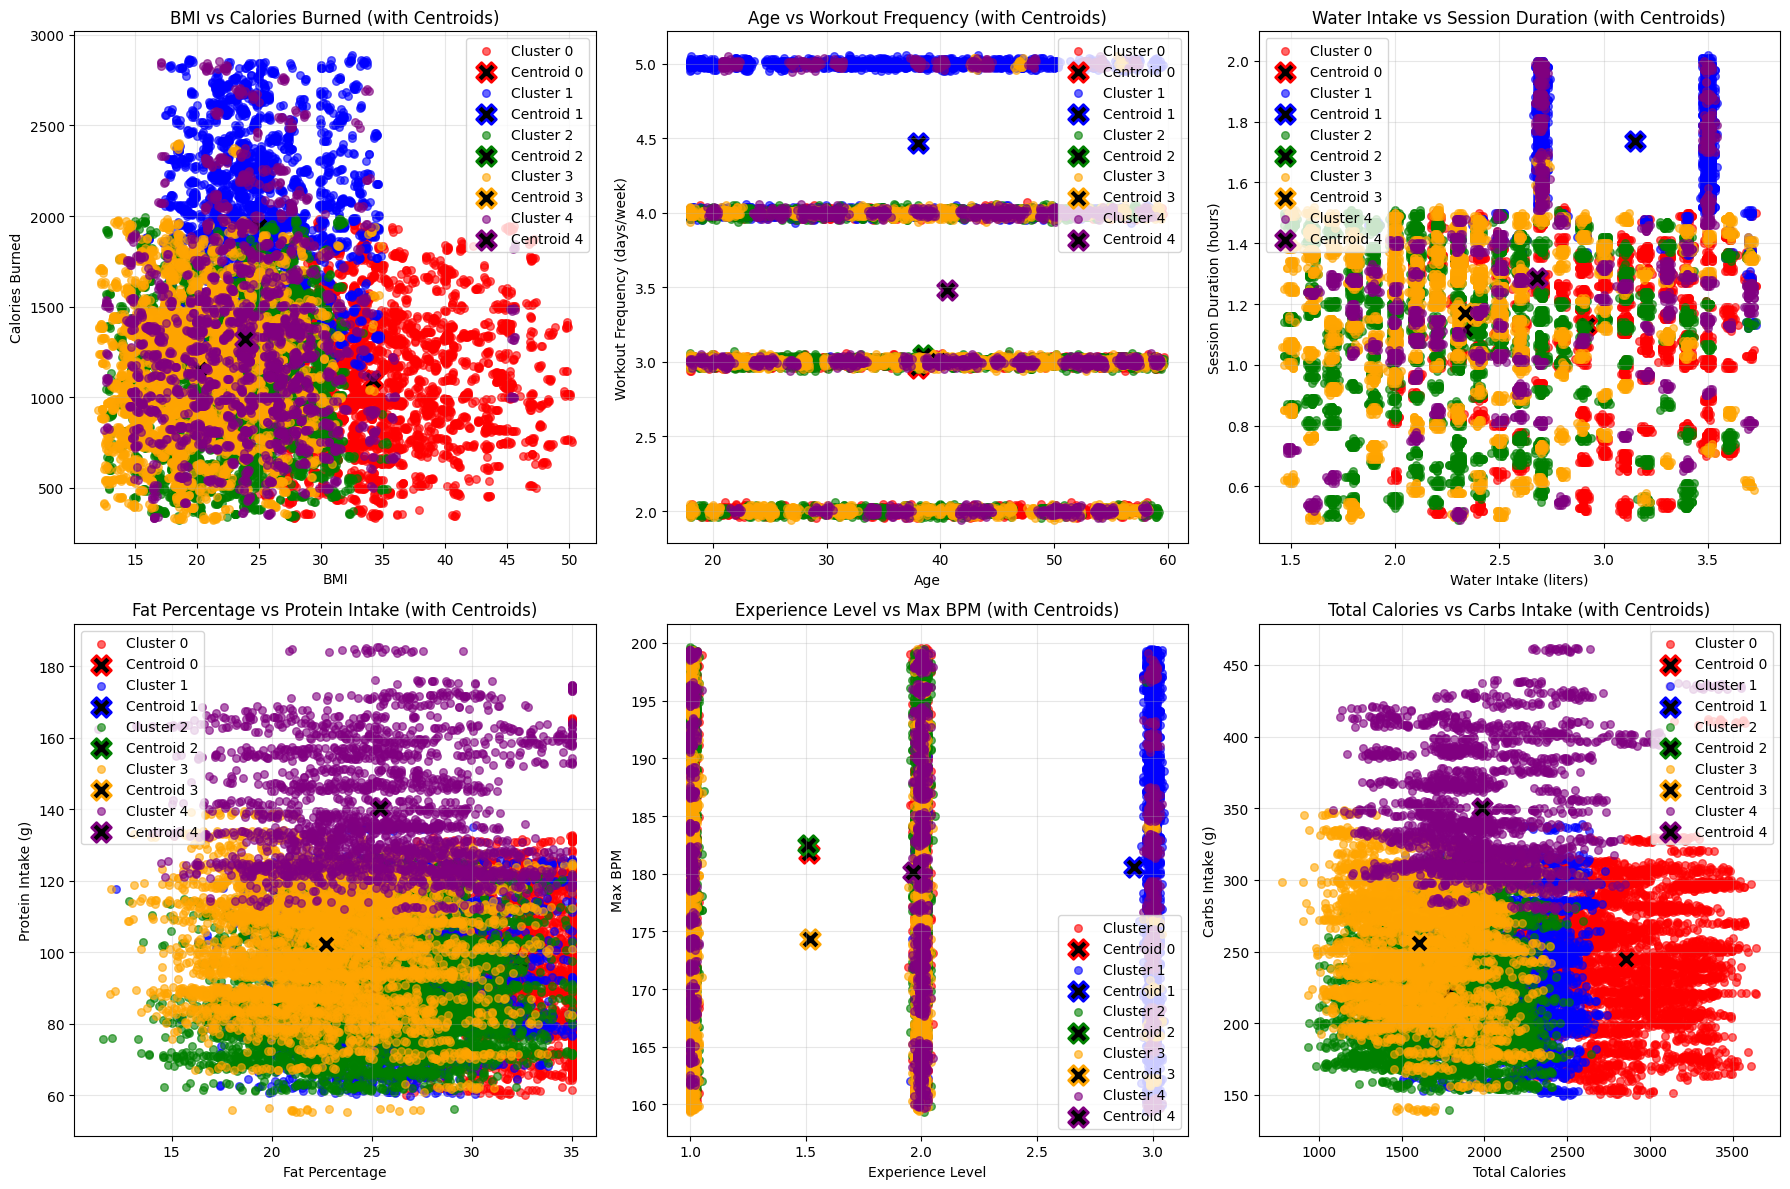

In [31]:
# Visualisasi Centroid K-Means
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
colors = ['red', 'blue', 'green', 'orange', 'purple']

# Dapatkan centroid dari model K-Means
centroids = kmeans_final.cluster_centers_

# Mapping centroid ke fitur asli (inverse transform)
centroids_original = scaler.inverse_transform(centroids)
centroid_df = pd.DataFrame(centroids_original, columns=numerical_features.columns)

print("=== KOORDINAT CENTROID SETIAP CLUSTER ===")
print(centroid_df.round(2))

# Plot 1: BMI vs Calories_Burned dengan centroid
axes[0,0].set_title('BMI vs Calories Burned (with Centroids)')
for i in range(optimal_k):
    cluster_data = final_data_clustered[final_data_clustered['Cluster'] == i]
    axes[0,0].scatter(cluster_data['BMI'], cluster_data['Calories_Burned'], 
                     c=colors[i], label=f'Cluster {i}', alpha=0.6, s=30)
    # Plot centroid
    axes[0,0].scatter(centroid_df.iloc[i]['BMI'], centroid_df.iloc[i]['Calories_Burned'], 
                     c='black', marker='X', s=200, linewidths=2, 
                     edgecolors=colors[i], label=f'Centroid {i}')

axes[0,0].set_xlabel('BMI')
axes[0,0].set_ylabel('Calories Burned')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Age vs Workout_Frequency dengan centroid
axes[0,1].set_title('Age vs Workout Frequency (with Centroids)')
for i in range(optimal_k):
    cluster_data = final_data_clustered[final_data_clustered['Cluster'] == i]
    axes[0,1].scatter(cluster_data['Age'], cluster_data['Workout_Frequency (days/week)'], 
                     c=colors[i], label=f'Cluster {i}', alpha=0.6, s=30)
    # Plot centroid
    axes[0,1].scatter(centroid_df.iloc[i]['Age'], centroid_df.iloc[i]['Workout_Frequency (days/week)'], 
                     c='black', marker='X', s=200, linewidths=2, 
                     edgecolors=colors[i], label=f'Centroid {i}')

axes[0,1].set_xlabel('Age')
axes[0,1].set_ylabel('Workout Frequency (days/week)')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Water_Intake vs Session_Duration dengan centroid
axes[0,2].set_title('Water Intake vs Session Duration (with Centroids)')
for i in range(optimal_k):
    cluster_data = final_data_clustered[final_data_clustered['Cluster'] == i]
    axes[0,2].scatter(cluster_data['Water_Intake (liters)'], cluster_data['Session_Duration (hours)'], 
                     c=colors[i], label=f'Cluster {i}', alpha=0.6, s=30)
    # Plot centroid
    axes[0,2].scatter(centroid_df.iloc[i]['Water_Intake (liters)'], centroid_df.iloc[i]['Session_Duration (hours)'], 
                     c='black', marker='X', s=200, linewidths=2, 
                     edgecolors=colors[i], label=f'Centroid {i}')

axes[0,2].set_xlabel('Water Intake (liters)')
axes[0,2].set_ylabel('Session Duration (hours)')
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# Plot 4: Fat_Percentage vs Proteins dengan centroid
axes[1,0].set_title('Fat Percentage vs Protein Intake (with Centroids)')
for i in range(optimal_k):
    cluster_data = final_data_clustered[final_data_clustered['Cluster'] == i]
    axes[1,0].scatter(cluster_data['Fat_Percentage'], cluster_data['Proteins'], 
                     c=colors[i], label=f'Cluster {i}', alpha=0.6, s=30)
    # Plot centroid
    axes[1,0].scatter(centroid_df.iloc[i]['Fat_Percentage'], centroid_df.iloc[i]['Proteins'], 
                     c='black', marker='X', s=200, linewidths=2, 
                     edgecolors=colors[i], label=f'Centroid {i}')

axes[1,0].set_xlabel('Fat Percentage')
axes[1,0].set_ylabel('Protein Intake (g)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot 5: Experience_Level vs Max_BPM dengan centroid
axes[1,1].set_title('Experience Level vs Max BPM (with Centroids)')
for i in range(optimal_k):
    cluster_data = final_data_clustered[final_data_clustered['Cluster'] == i]
    axes[1,1].scatter(cluster_data['Experience_Level'], cluster_data['Max_BPM'], 
                     c=colors[i], label=f'Cluster {i}', alpha=0.6, s=30)
    # Plot centroid
    axes[1,1].scatter(centroid_df.iloc[i]['Experience_Level'], centroid_df.iloc[i]['Max_BPM'], 
                     c='black', marker='X', s=200, linewidths=2, 
                     edgecolors=colors[i], label=f'Centroid {i}')

axes[1,1].set_xlabel('Experience Level')
axes[1,1].set_ylabel('Max BPM')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

# Plot 6: Calories vs Carbs dengan centroid
axes[1,2].set_title('Total Calories vs Carbs Intake (with Centroids)')
for i in range(optimal_k):
    cluster_data = final_data_clustered[final_data_clustered['Cluster'] == i]
    axes[1,2].scatter(cluster_data['Calories'], cluster_data['Carbs'], 
                     c=colors[i], label=f'Cluster {i}', alpha=0.6, s=30)
    # Plot centroid
    axes[1,2].scatter(centroid_df.iloc[i]['Calories'], centroid_df.iloc[i]['Carbs'], 
                     c='black', marker='X', s=200, linewidths=2, 
                     edgecolors=colors[i], label=f'Centroid {i}')

axes[1,2].set_xlabel('Total Calories')
axes[1,2].set_ylabel('Carbs Intake (g)')
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
# Analisis mendalam karakteristik lifestyle setiap cluster
print("=== PROFIL LIFESTYLE SETIAP CLUSTER ===\n")

for cluster_id in range(optimal_k):
    cluster_data = final_data_clustered[final_data_clustered['Cluster'] == cluster_id]
    
    print(f"CLUSTER {cluster_id} (n={len(cluster_data)} orang)")
    print("="*50)
    
    # Demografis
    print("Demografis:")
    print(f"  - Usia rata-rata: {cluster_data['Age'].mean():.1f} tahun")
    print(f"  - BMI rata-rata: {cluster_data['BMI'].mean():.1f}")
    print(f"  - Gender dominan: {cluster_data['Gender'].mode().iloc[0] if not cluster_data['Gender'].mode().empty else 'N/A'}")
    
    # Aktivitas Fisik
    print("\nAktivitas Fisik:")
    print(f"  - Frekuensi workout: {cluster_data['Workout_Frequency (days/week)'].mean():.1f} hari/minggu")
    print(f"  - Durasi sesi: {cluster_data['Session_Duration (hours)'].mean():.1f} jam")
    print(f"  - Kalori terbakar: {cluster_data['Calories_Burned'].mean():.0f} kalori")
    print(f"  - Level pengalaman: {cluster_data['Experience_Level'].mean():.1f}")
    print(f"  - Workout type dominan: {cluster_data['Workout_Type'].mode().iloc[0] if not cluster_data['Workout_Type'].mode().empty else 'N/A'}")
    
    # Kesehatan & Nutrisi
    print("\nKesehatan & Nutrisi:")
    print(f"  - Fat percentage: {cluster_data['Fat_Percentage'].mean():.1f}%")
    print(f"  - Water intake: {cluster_data['Water_Intake (liters)'].mean():.1f} liter/hari")
    print(f"  - Total kalori makanan: {cluster_data['Calories'].mean():.0f} kalori")
    print(f"  - Protein: {cluster_data['Proteins'].mean():.1f}g")
    print(f"  - Karbohidrat: {cluster_data['Carbs'].mean():.1f}g")
    print(f"  - Lemak: {cluster_data['Fats'].mean():.1f}g")
    
    # Heart Rate
    print("\nDetak Jantung:")
    print(f"  - Resting BPM: {cluster_data['Resting_BPM'].mean():.0f}")
    print(f"  - Average BPM: {cluster_data['Avg_BPM'].mean():.0f}")
    print(f"  - Max BPM: {cluster_data['Max_BPM'].mean():.0f}")
    
    print("\n" + "="*50 + "\n")

=== PROFIL LIFESTYLE SETIAP CLUSTER ===

CLUSTER 0 (n=3814 orang)
Demografis:
  - Usia rata-rata: 38.0 tahun
  - BMI rata-rata: 34.2
  - Gender dominan: Male

Aktivitas Fisik:
  - Frekuensi workout: 3.0 hari/minggu
  - Durasi sesi: 1.1 jam
  - Kalori terbakar: 1096 kalori
  - Level pengalaman: 1.5
  - Workout type dominan: Yoga

Kesehatan & Nutrisi:
  - Fat percentage: 32.4%
  - Water intake: 2.9 liter/hari
  - Total kalori makanan: 2856 kalori
  - Protein: 97.9g
  - Karbohidrat: 244.6g
  - Lemak: 65.2g

Detak Jantung:
  - Resting BPM: 61
  - Average BPM: 145
  - Max BPM: 182


CLUSTER 1 (n=3493 orang)
Demografis:
  - Usia rata-rata: 38.0 tahun
  - BMI rata-rata: 25.0
  - Gender dominan: Male

Aktivitas Fisik:
  - Frekuensi workout: 4.5 hari/minggu
  - Durasi sesi: 1.7 jam
  - Kalori terbakar: 1943 kalori
  - Level pengalaman: 2.9
  - Workout type dominan: HIIT

Kesehatan & Nutrisi:
  - Fat percentage: 25.9%
  - Water intake: 3.1 liter/hari
  - Total kalori makanan: 2106 kalori
  - Pro

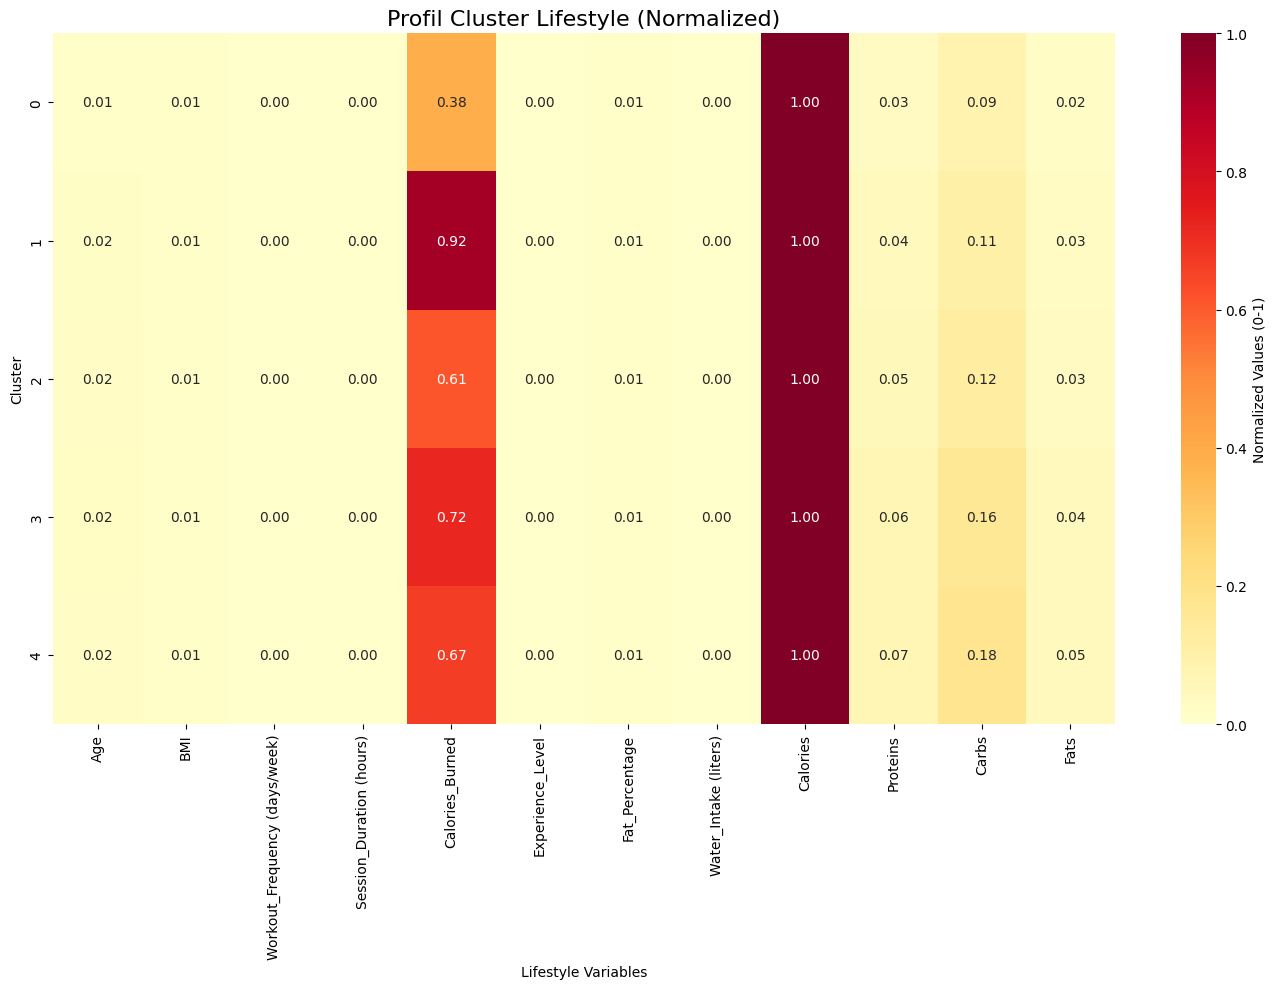

In [29]:
# Heatmap perbandingan cluster
plt.figure(figsize=(14, 10))

# Pilih variabel kunci untuk analisis
key_variables = ['Age', 'BMI', 'Workout_Frequency (days/week)', 'Session_Duration (hours)', 
                'Calories_Burned', 'Experience_Level', 'Fat_Percentage', 
                'Water_Intake (liters)', 'Calories', 'Proteins', 'Carbs', 'Fats']

cluster_profiles = final_data_clustered.groupby('Cluster')[key_variables].mean()

# Normalisasi untuk visualisasi yang lebih baik
from sklearn.preprocessing import MinMaxScaler
scaler_viz = MinMaxScaler()
cluster_profiles_scaled = pd.DataFrame(
    scaler_viz.fit_transform(cluster_profiles.T).T,
    columns=cluster_profiles.columns,
    index=cluster_profiles.index
)

sns.heatmap(cluster_profiles_scaled, 
            annot=True, 
            cmap='YlOrRd', 
            fmt='.2f',
            cbar_kws={'label': 'Normalized Values (0-1)'})
plt.title('Profil Cluster Lifestyle (Normalized)', fontsize=16)
plt.xlabel('Lifestyle Variables')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

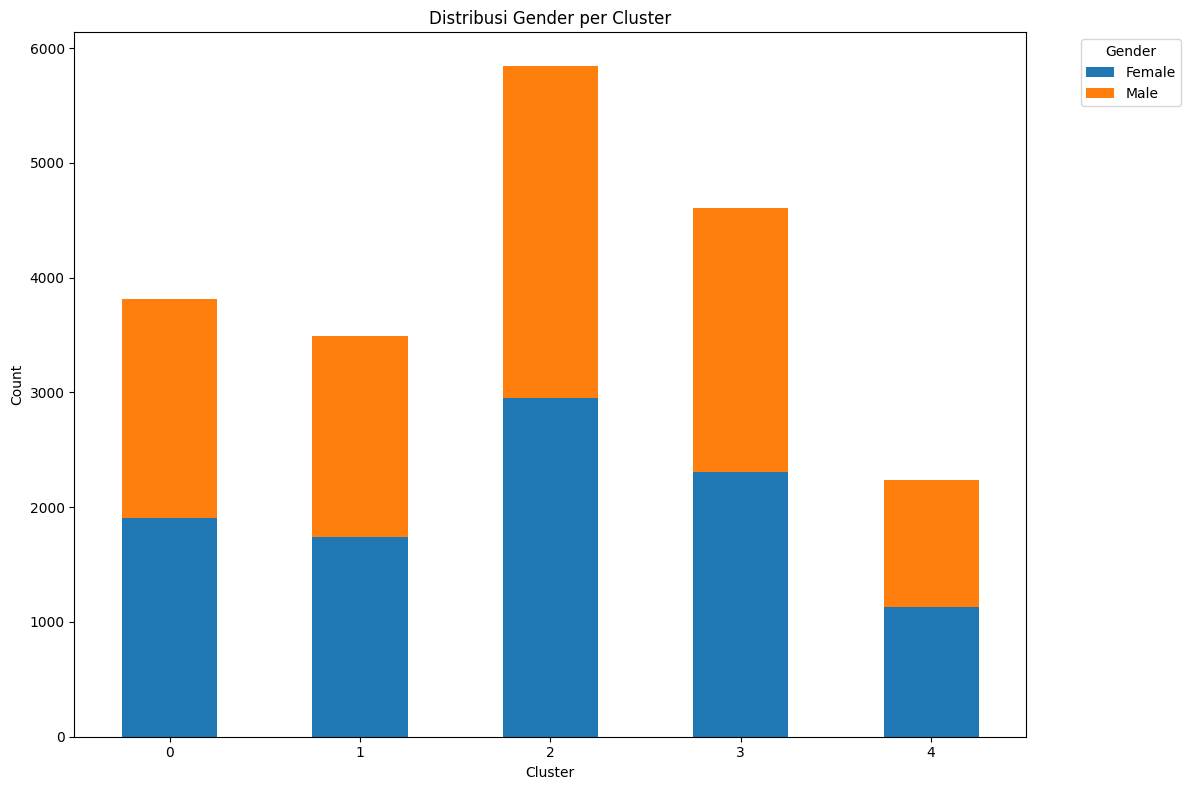


Proporsi Gender per Cluster:
Gender   Female   Male
Cluster               
0         0.499  0.501
1         0.499  0.501
2         0.504  0.496
3         0.500  0.500
4         0.504  0.496
--------------------------------------------------


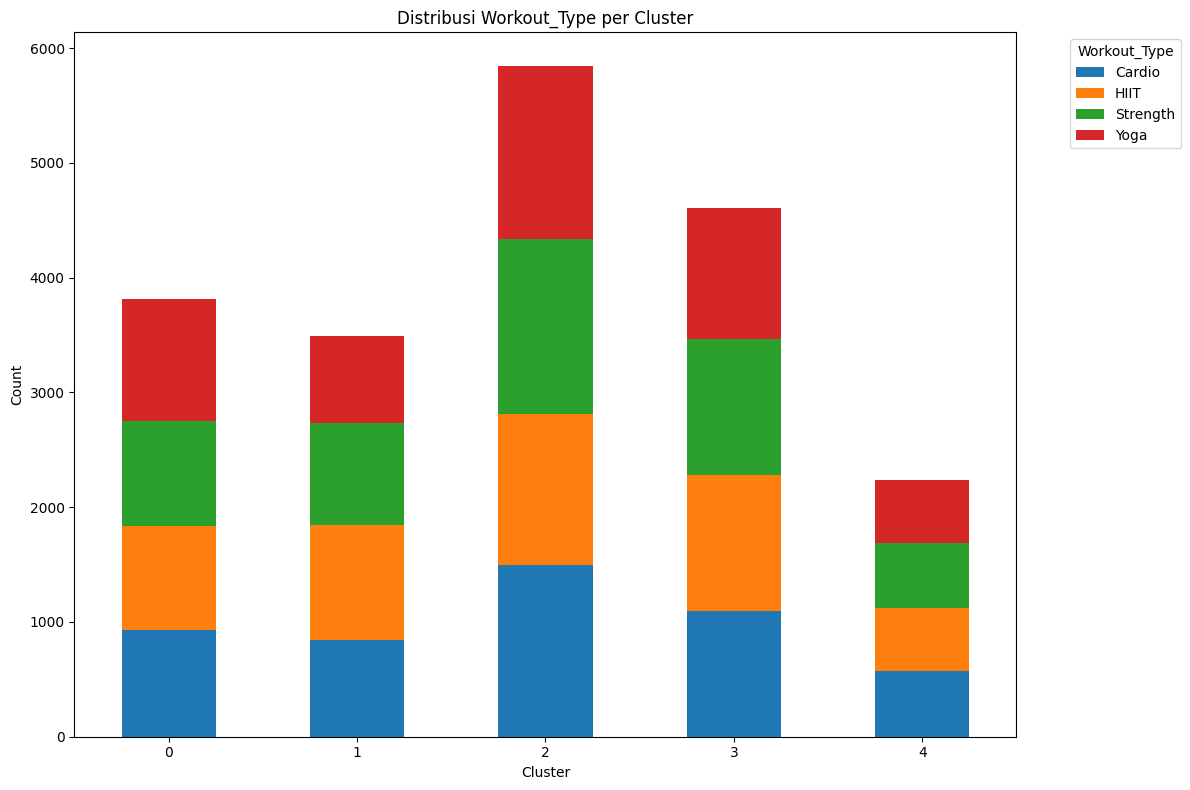


Proporsi Workout_Type per Cluster:
Workout_Type  Cardio   HIIT  Strength   Yoga
Cluster                                     
0              0.243  0.238     0.240  0.279
1              0.240  0.288     0.254  0.218
2              0.255  0.226     0.260  0.259
3              0.238  0.258     0.258  0.247
4              0.254  0.247     0.251  0.247
--------------------------------------------------


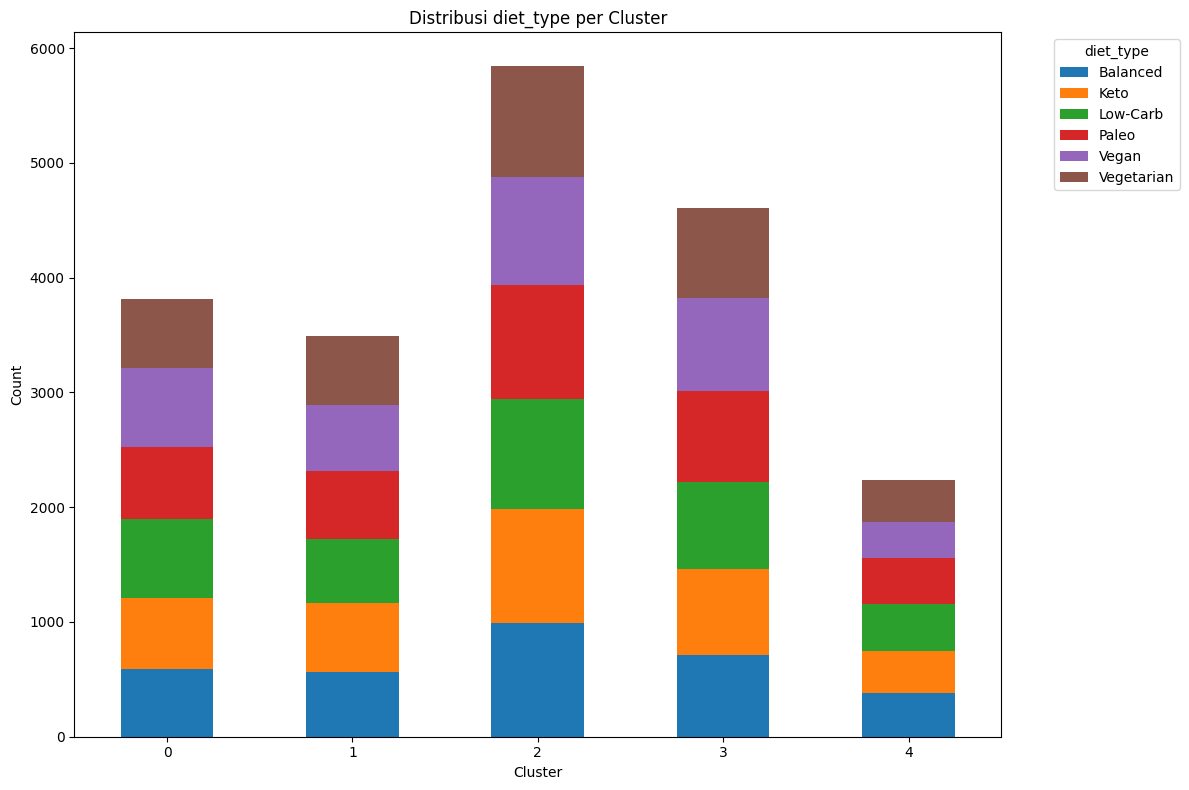


Proporsi diet_type per Cluster:
diet_type  Balanced   Keto  Low-Carb  Paleo  Vegan  Vegetarian
Cluster                                                       
0             0.154  0.163     0.180  0.164  0.180       0.159
1             0.161  0.172     0.159  0.171  0.163       0.173
2             0.170  0.170     0.164  0.170  0.161       0.166
3             0.154  0.163     0.166  0.172  0.175       0.171
4             0.172  0.160     0.186  0.176  0.142       0.164
--------------------------------------------------


In [30]:
# Distribusi variabel kategorikal per cluster
categorical_vars = ['Gender', 'Workout_Type', 'diet_type']

for var in categorical_vars:
    if var in final_data_clustered.columns:
        plt.figure(figsize=(12, 8))
        
        # Buat crosstab
        crosstab = pd.crosstab(final_data_clustered['Cluster'], final_data_clustered[var])
        
        # Plot sebagai stacked bar
        crosstab.plot(kind='bar', stacked=True, ax=plt.gca())
        plt.title(f'Distribusi {var} per Cluster')
        plt.xlabel('Cluster')
        plt.ylabel('Count')
        plt.legend(title=var, bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()
        
        # Print proporsi
        print(f"\nProporsi {var} per Cluster:")
        prop_table = pd.crosstab(final_data_clustered['Cluster'], final_data_clustered[var], normalize='index')
        print(prop_table.round(3))
        print("-"*50)

## Aturan Asosiasi

In [33]:
!pip install mlxtend

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ----------------------- ---------------- 0.8/1.4 MB 1.2 MB/s eta 0:00:01
   ----------------------- ---------------- 0.8/1.4 MB 1.2 MB/s eta 0:00:01
   ------------------------------- -------- 1.0/1.4 MB 1.2 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 1.2 MB/s  0:00:01


In [35]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

In [36]:
# 1. Persiapan data - Konversi variabel numerik ke kategorikal
data_arm = final_data.copy()

In [37]:
# Binning Age
data_arm['Age_Group'] = pd.cut(data_arm['Age'], 
                              bins=[0, 25, 35, 45, 100], 
                              labels=['Young', 'Adult', 'Middle_Age', 'Senior'])

In [38]:
# Binning BMI
data_arm['BMI_Category'] = pd.cut(data_arm['BMI'], 
                                 bins=[0, 18.5, 25, 30, 100], 
                                 labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

In [39]:
# Binning Workout Frequency
data_arm['Workout_Freq_Cat'] = pd.cut(data_arm['Workout_Frequency (days/week)'], 
                                      bins=[0, 2, 4, 7], 
                                      labels=['Low_Freq', 'Medium_Freq', 'High_Freq'])

In [40]:
# Binning Experience Level
data_arm['Experience_Cat'] = data_arm['Experience_Level'].map({1: 'Beginner', 2: 'Intermediate', 3: 'Expert'})

In [41]:
# Binning Calories Burned
data_arm['Calories_Burned_Cat'] = pd.cut(data_arm['Calories_Burned'], 
                                         bins=[0, 300, 600, 2000], 
                                         labels=['Low_Burn', 'Medium_Burn', 'High_Burn'])

In [42]:
# Binning Water Intake
data_arm['Water_Intake_Cat'] = pd.cut(data_arm['Water_Intake (liters)'], 
                                      bins=[0, 2, 3, 10], 
                                      labels=['Low_Water', 'Medium_Water', 'High_Water'])

In [43]:
# Binning Session Duration
data_arm['Session_Duration_Cat'] = pd.cut(data_arm['Session_Duration (hours)'], 
                                          bins=[0, 1, 1.5, 5], 
                                          labels=['Short_Session', 'Medium_Session', 'Long_Session'])

In [44]:
print(f"Sample data setelah binning:")
print(data_arm[['Age_Group', 'BMI_Category', 'Workout_Freq_Cat', 'Experience_Cat']].head())

Sample data setelah binning:
    Age_Group BMI_Category Workout_Freq_Cat Experience_Cat
0       Adult       Normal      Medium_Freq            NaN
1       Young       Normal      Medium_Freq            NaN
2       Adult       Normal      Medium_Freq            NaN
3  Middle_Age        Obese      Medium_Freq            NaN
4      Senior  Underweight      Medium_Freq   Intermediate


In [45]:
# 2. Buat transactions dari data kategorikal
categorical_vars = [
    'Age_Group', 'Gender', 'BMI_Category', 'Workout_Type',
    'Workout_Freq_Cat', 'Experience_Cat', 'Calories_Burned_Cat',
    'Water_Intake_Cat', 'Session_Duration_Cat', 'diet_type'
    ]

# Buat list transactions
transactions = []
for idx, row in data_arm.iterrows():
    transaction = []
    for var in categorical_vars:
        if pd.notna(row[var]):
            transaction.append(f"{var}_{row[var]}")
    transactions.append(transaction)

print(f"Total transactions: {len(transactions)}")
print(f"Sample transaction: {transactions[0]}")
print(f"Sample transaction 2: {transactions[1]}")

Total transactions: 20000
Sample transaction: ['Age_Group_Adult', 'Gender_Male', 'BMI_Category_Normal', 'Workout_Type_Strength', 'Workout_Freq_Cat_Medium_Freq', 'Calories_Burned_Cat_High_Burn', 'Water_Intake_Cat_Low_Water', 'Session_Duration_Cat_Short_Session', 'diet_type_Vegan']
Sample transaction 2: ['Age_Group_Young', 'Gender_Female', 'BMI_Category_Normal', 'Workout_Type_HIIT', 'Workout_Freq_Cat_Medium_Freq', 'Calories_Burned_Cat_High_Burn', 'Water_Intake_Cat_Low_Water', 'Session_Duration_Cat_Medium_Session', 'diet_type_Vegetarian']


In [47]:
# 3. Encode transactions untuk apriori
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(f"Shape of encoded data: {df_encoded.shape}")
print(f"Sample encoded data:")
df_encoded.head()

Shape of encoded data: (20000, 34)
Sample encoded data:


,Age_Group_Adult,Age_Group_Middle_Age,Age_Group_Senior,Age_Group_Young,BMI_Category_Normal,BMI_Category_Obese,BMI_Category_Overweight,BMI_Category_Underweight,Calories_Burned_Cat_High_Burn,Calories_Burned_Cat_Medium_Burn,...,Workout_Type_Cardio,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga,diet_type_Balanced,diet_type_Keto,diet_type_Low-Carb,diet_type_Paleo,diet_type_Vegan,diet_type_Vegetarian
0,True,False,False,False,True,False,False,False,True,False,...,False,False,True,False,False,False,False,False,True,False
1,False,False,False,True,True,False,False,False,True,False,...,False,True,False,False,False,False,False,False,False,True
2,True,False,False,False,True,False,False,False,True,False,...,True,False,False,False,False,False,False,True,False,False
3,False,True,False,False,False,True,False,False,True,False,...,False,True,False,False,False,False,False,True,False,False
4,False,False,True,False,False,False,False,True,True,False,...,False,False,True,False,False,False,False,False,True,False


In [49]:
# 4. Find frequent itemsets
min_support = 0.01  # 1% minimum support
frequent_itemsets = apriori(df_encoded, min_support=min_support, use_colnames=True)

print(f"Frequent itemsets found: {len(frequent_itemsets)}")
if len(frequent_itemsets) > 0:
    print("Top 10 frequent itemsets:")
    print(frequent_itemsets.nlargest(10, 'support'))
else:
    print("No frequent itemsets found. Lowering support threshold...")
    min_support = 0.005
    frequent_itemsets = apriori(df_encoded, min_support=min_support, use_colnames=True)
    print(f"Frequent itemsets found with lower threshold: {len(frequent_itemsets)}")

Frequent itemsets found: 10724
Top 10 frequent itemsets:
     support                                           itemsets
8    0.85030                    (Calories_Burned_Cat_High_Burn)
23   0.64910                     (Workout_Freq_Cat_Medium_Freq)
16   0.60640              (Session_Duration_Cat_Medium_Session)
259  0.60630  (Session_Duration_Cat_Medium_Session, Calories...
266  0.58440  (Calories_Burned_Cat_High_Burn, Workout_Freq_C...
20   0.53445                    (Water_Intake_Cat_Medium_Water)
13   0.50140                                    (Gender_Female)
14   0.49860                                      (Gender_Male)
263  0.45865  (Water_Intake_Cat_Medium_Water, Calories_Burne...
397  0.45865  (Session_Duration_Cat_Medium_Session, Workout_...


In [50]:
# 5. Generate association rules
if len(frequent_itemsets) > 0:
    print("\n=== GENERATING ASSOCIATION RULES ===")
    
    min_confidence = 0.5  # 50% minimum confidence
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence)
    
    # Filter by lift
    min_lift = 1.1
    rules = rules[rules['lift'] >= min_lift]
    
    print(f"Association rules found: {len(rules)}")
    
    if len(rules) > 0:
        # Sort by lift
        rules_sorted = rules.sort_values('lift', ascending=False)
        
        print("\n=== TOP 15 ASSOCIATION RULES ===")
        for idx, row in rules_sorted.head(15).iterrows():
            antecedents = list(row['antecedents'])
            consequents = list(row['consequents'])
            
            print(f"\nRule {idx + 1}:")
            print(f"  If: {' AND '.join(antecedents)}")
            print(f"  Then: {' AND '.join(consequents)}")
            print(f"  Support: {row['support']:.3f}")
            print(f"  Confidence: {row['confidence']:.3f}")
            print(f"  Lift: {row['lift']:.3f}")
            print("-" * 80)
    else:
        print("No rules found with current thresholds. Trying lower thresholds...")
        min_confidence = 0.3
        rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence)
        rules = rules[rules['lift'] >= 1.05]
        print(f"Rules found with lower thresholds: {len(rules)}")
else:
    print("Cannot generate rules - no frequent itemsets found")


=== GENERATING ASSOCIATION RULES ===
Association rules found: 12573

=== TOP 15 ASSOCIATION RULES ===

Rule 19719:
  If: Session_Duration_Cat_Short_Session AND Workout_Freq_Cat_Low_Freq AND Workout_Type_Yoga
  Then: Experience_Cat_Beginner AND Calories_Burned_Cat_Medium_Burn
  Support: 0.010
  Confidence: 0.576
  Lift: 14.482
--------------------------------------------------------------------------------

Rule 19714:
  If: Workout_Type_Yoga AND Experience_Cat_Beginner AND Session_Duration_Cat_Short_Session AND Workout_Freq_Cat_Low_Freq
  Then: Calories_Burned_Cat_Medium_Burn
  Support: 0.010
  Confidence: 0.870
  Lift: 13.969
--------------------------------------------------------------------------------

Rule 19718:
  If: Experience_Cat_Beginner AND Calories_Burned_Cat_Medium_Burn AND Workout_Freq_Cat_Low_Freq
  Then: Session_Duration_Cat_Short_Session AND Workout_Type_Yoga
  Support: 0.010
  Confidence: 0.714
  Lift: 13.829
---------------------------------------------------------


=== VISUALISASI ASSOCIATION RULES ===


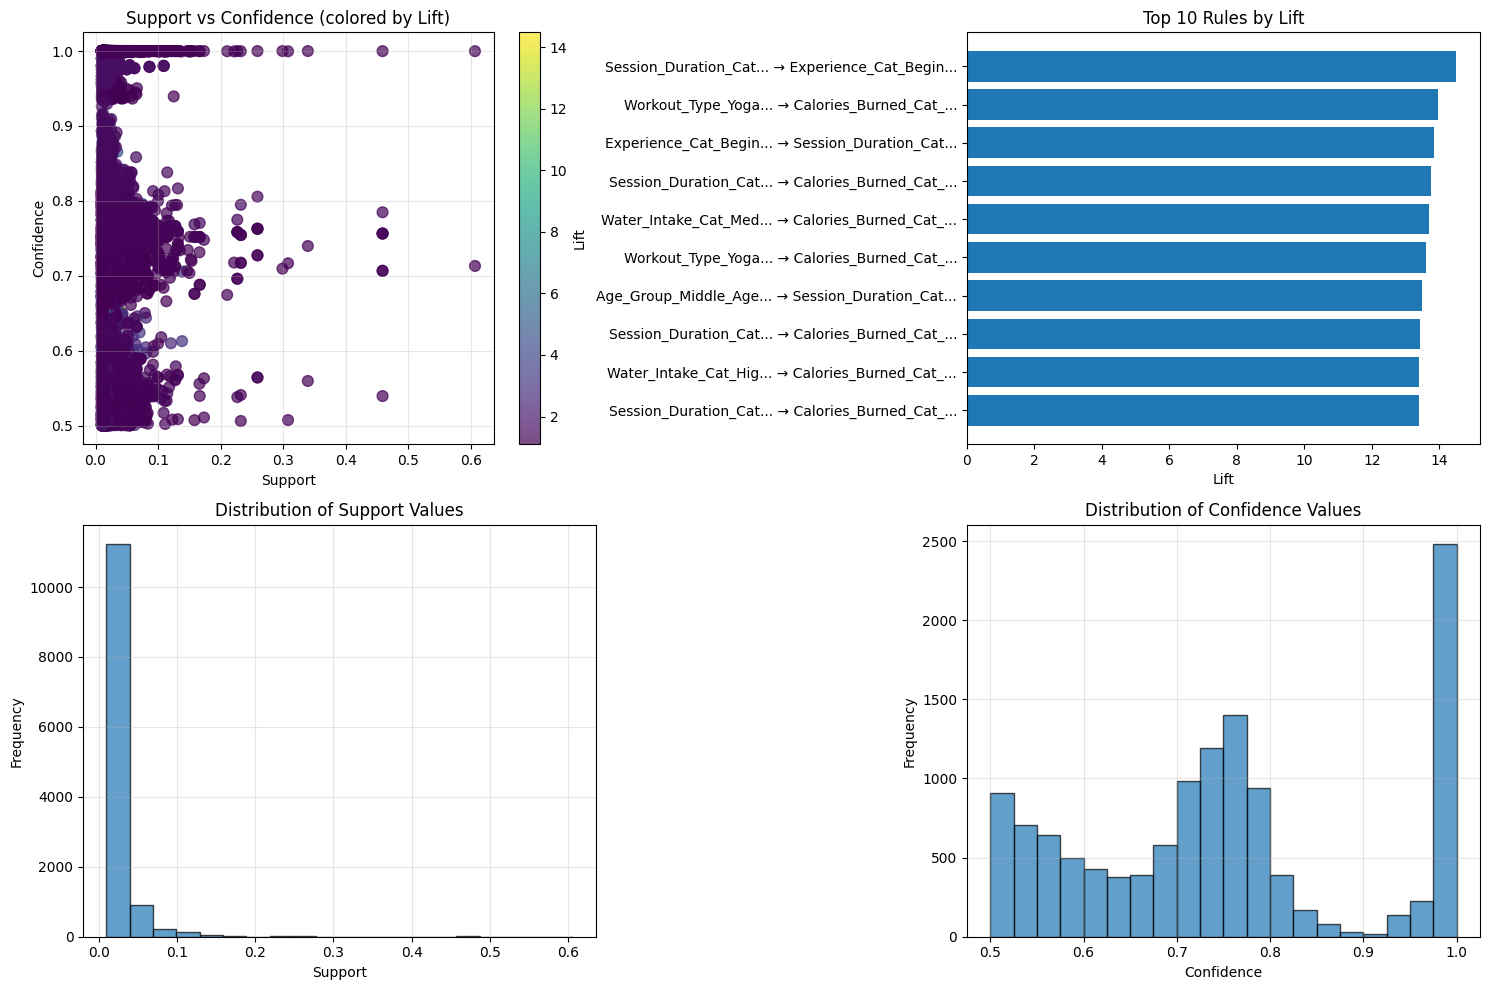

In [51]:
# 6. Visualisasi hasil association rules
if len(rules) > 0:
    print("\n=== VISUALISASI ASSOCIATION RULES ===")
    
    # Plot 1: Support vs Confidence colored by Lift
    plt.figure(figsize=(15, 10))
    
    plt.subplot(2, 2, 1)
    scatter = plt.scatter(rules['support'], rules['confidence'], 
                         c=rules['lift'], cmap='viridis', s=60, alpha=0.7)
    plt.colorbar(scatter, label='Lift')
    plt.xlabel('Support')
    plt.ylabel('Confidence')
    plt.title('Support vs Confidence (colored by Lift)')
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Top rules by lift
    plt.subplot(2, 2, 2)
    top_10_lift = rules.nlargest(10, 'lift')
    rule_labels = []
    for _, rule in top_10_lift.iterrows():
        antecedent = list(rule['antecedents'])[0][:20] + "..."
        consequent = list(rule['consequents'])[0][:20] + "..."
        rule_labels.append(f"{antecedent} → {consequent}")
    
    plt.barh(range(len(top_10_lift)), top_10_lift['lift'])
    plt.yticks(range(len(top_10_lift)), rule_labels)
    plt.xlabel('Lift')
    plt.title('Top 10 Rules by Lift')
    plt.gca().invert_yaxis()
    
    # Plot 3: Support distribution
    plt.subplot(2, 2, 3)
    plt.hist(rules['support'], bins=20, alpha=0.7, edgecolor='black')
    plt.xlabel('Support')
    plt.ylabel('Frequency')
    plt.title('Distribution of Support Values')
    plt.grid(True, alpha=0.3)
    
    # Plot 4: Confidence distribution
    plt.subplot(2, 2, 4)
    plt.hist(rules['confidence'], bins=20, alpha=0.7, edgecolor='black')
    plt.xlabel('Confidence')
    plt.ylabel('Frequency')
    plt.title('Distribution of Confidence Values')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


=== SUMMARY STATISTICS ===
Total rules: 12573
Average Support: 0.023
Average Confidence: 0.751
Average Lift: 1.513
Max Lift: 14.482
Min Lift: 1.100

=== MOST FREQUENT ANTECEDENTS ===
Session_Duration_Cat_Medium_Session    4938
Calories_Burned_Cat_High_Burn          3625
Workout_Freq_Cat_Medium_Freq           3571
Water_Intake_Cat_Medium_Water          3060
Gender_Female                          2571
Gender_Male                            2564
Age_Group_Senior                       1940
BMI_Category_Normal                    1746
Experience_Cat_Intermediate            1558
Workout_Type_HIIT                      1409
Name: count, dtype: int64

=== MOST FREQUENT CONSEQUENTS ===
Calories_Burned_Cat_High_Burn          5585
Session_Duration_Cat_Medium_Session    4145
Workout_Freq_Cat_Medium_Freq           3693
Water_Intake_Cat_Medium_Water          1337
Experience_Cat_Beginner                 453
Gender_Female                           375
Gender_Male                             310
Session

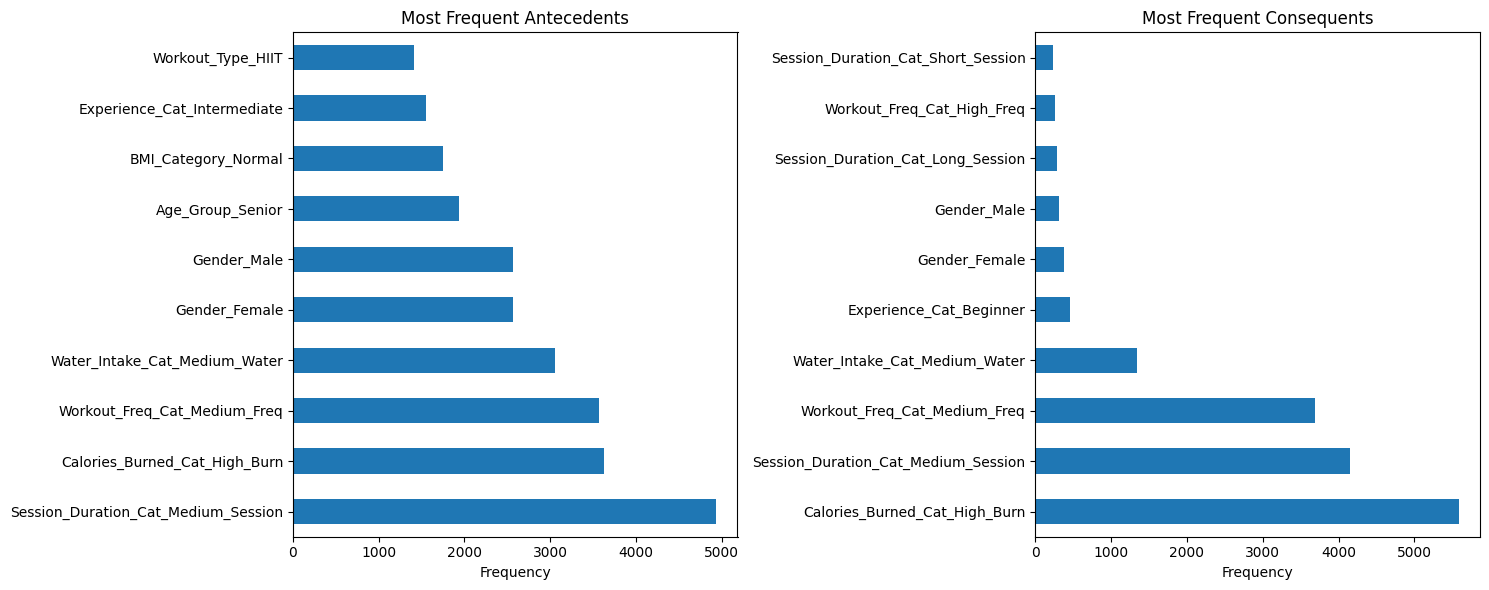

In [52]:
# 7. Summary statistics dan analisis
if len(rules) > 0:
    print("\n=== SUMMARY STATISTICS ===")
    print(f"Total rules: {len(rules)}")
    print(f"Average Support: {rules['support'].mean():.3f}")
    print(f"Average Confidence: {rules['confidence'].mean():.3f}")
    print(f"Average Lift: {rules['lift'].mean():.3f}")
    print(f"Max Lift: {rules['lift'].max():.3f}")
    print(f"Min Lift: {rules['lift'].min():.3f}")
    
    # Most frequent antecedents and consequents
    all_antecedents = []
    all_consequents = []
    
    for _, rule in rules.iterrows():
        all_antecedents.extend(list(rule['antecedents']))
        all_consequents.extend(list(rule['consequents']))
    
    print(f"\n=== MOST FREQUENT ANTECEDENTS ===")
    antecedent_counts = pd.Series(all_antecedents).value_counts().head(10)
    print(antecedent_counts)
    
    print(f"\n=== MOST FREQUENT CONSEQUENTS ===")
    consequent_counts = pd.Series(all_consequents).value_counts().head(10)
    print(consequent_counts)
    
    # Visualisasi frequent antecedents dan consequents
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot antecedents
    antecedent_counts.plot(kind='barh', ax=axes[0])
    axes[0].set_title('Most Frequent Antecedents')
    axes[0].set_xlabel('Frequency')
    
    # Plot consequents
    consequent_counts.plot(kind='barh', ax=axes[1])
    axes[1].set_title('Most Frequent Consequents')
    axes[1].set_xlabel('Frequency')
    
    plt.tight_layout()
    plt.show()

Frequent Antecedents adalah item atau kondisi yang paling sering muncul sebagai bagian "IF" (syarat/kondisi) dalam aturan asosiasi yang ditemukan.

Penjelasan:
Antecedent = Bagian "IF" dari aturan asosiasi

Dalam aturan "IF A THEN B", maka A adalah antecedent
Antecedent adalah kondisi atau item yang menjadi pemicu/penyebab
Frequent Antecedents = Antecedent yang paling sering muncul di berbagai aturan

Contoh dalam konteks lifestyle data:
Jika ditemukan aturan-aturan seperti:

1. IF Age_Group_Young THEN Workout_Type_HIIT
2. IF Age_Group_Young THEN High_Freq_Workout
3. IF BMI_Category_Normal THEN Medium_Water_Intake
4. IF BMI_Category_Normal THEN Balanced_Diet

Maka Frequent Antecedents adalah:

* Age_Group_Young (muncul 2 kali sebagai antecedent)
* BMI_Category_Normal (muncul 2 kali sebagai antecedent)

## Principal Component Analysis (PCA)

In [53]:
from sklearn.decomposition import PCA

In [54]:
# 1. Persiapan data untuk PCA
# Gunakan hanya variabel numerik
numerical_features_pca = final_data.select_dtypes(include=[np.number])
print(f"Variabel numerik untuk PCA: {list(numerical_features_pca.columns)}")
print(f"Shape data: {numerical_features_pca.shape}")

Variabel numerik untuk PCA: ['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'Daily meals frequency', 'Physical exercise', 'Carbs', 'Proteins', 'Fats', 'Calories', 'sugar_g', 'sodium_mg', 'cholesterol_mg', 'serving_size_g', 'prep_time_min', 'cook_time_min', 'rating', 'Sets', 'Reps', 'Burns Calories (per 30 min)', 'BMI_calc', 'cal_from_macros', 'pct_carbs', 'protein_per_kg', 'pct_HRR', 'pct_maxHR', 'cal_balance', 'lean_mass_kg', 'expected_burn', 'Burns Calories (per 30 min)_bc']
Shape data: (20000, 39)


In [55]:
# Handle missing values jika ada
numerical_features_pca = numerical_features_pca.fillna(numerical_features_pca.mean())

In [57]:
# Standardisasi data (penting untuk PCA)
scaler_pca = StandardScaler()
scaled_data_pca = scaler_pca.fit_transform(numerical_features_pca)

In [58]:
# 2. fit pca
pca = PCA()
pca.fit(scaled_data_pca)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [59]:
# Hitung explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

print(f"Total komponen: {len(explained_variance_ratio)}")
print(f"Explained variance ratio untuk 10 komponen pertama:")
for i in range(min(10, len(explained_variance_ratio))):
    print(f"PC{i+1}: {explained_variance_ratio[i]:.4f} ({explained_variance_ratio[i]*100:.2f}%)")

Total komponen: 39
Explained variance ratio untuk 10 komponen pertama:
PC1: 0.1727 (17.27%)
PC2: 0.1240 (12.40%)
PC3: 0.1141 (11.41%)
PC4: 0.0776 (7.76%)
PC5: 0.0586 (5.86%)
PC6: 0.0435 (4.35%)
PC7: 0.0302 (3.02%)
PC8: 0.0283 (2.83%)
PC9: 0.0276 (2.76%)
PC10: 0.0265 (2.65%)


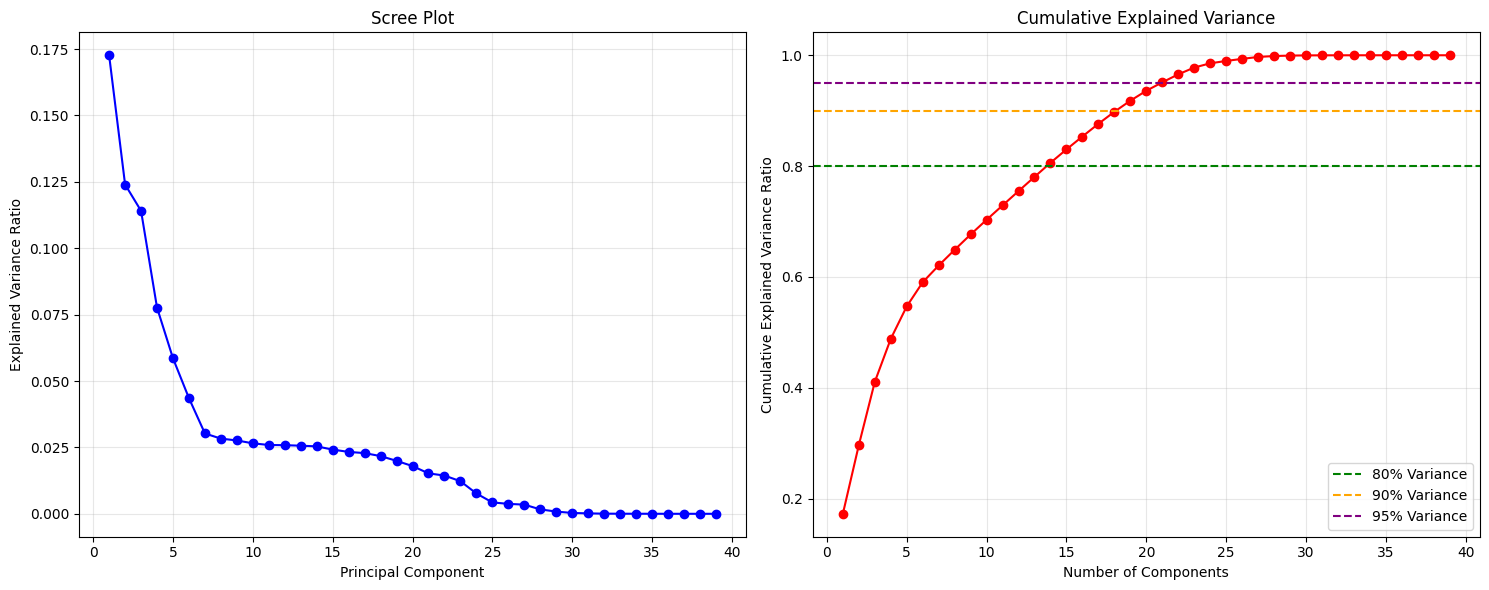

In [60]:
# 3. Visualisasi Scree Plot dan Cumulative Variance
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scree Plot
axes[0].plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, 'bo-')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')
axes[0].grid(True, alpha=0.3)

# Cumulative Variance Plot
axes[1].plot(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio, 'ro-')
axes[1].axhline(y=0.8, color='g', linestyle='--', label='80% Variance')
axes[1].axhline(y=0.9, color='orange', linestyle='--', label='90% Variance')
axes[1].axhline(y=0.95, color='purple', linestyle='--', label='95% Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance Ratio')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [61]:
# Tentukan jumlah komponen untuk mencapai 80%, 90%, dan 95% variance
n_components_80 = np.argmax(cumulative_variance_ratio >= 0.8) + 1
n_components_90 = np.argmax(cumulative_variance_ratio >= 0.9) + 1
n_components_95 = np.argmax(cumulative_variance_ratio >= 0.95) + 1

print(f"\nJumlah komponen untuk menjelaskan:")
print(f"80% variance: {n_components_80} komponen")
print(f"90% variance: {n_components_90} komponen") 
print(f"95% variance: {n_components_95} komponen")


Jumlah komponen untuk menjelaskan:
80% variance: 14 komponen
90% variance: 19 komponen
95% variance: 21 komponen


Varians adalah ukuran statistik yang menunjukkan seberapa jauh sekumpulan data menyebar dari nilai rata-ratanya (mean). Semakin tinggi varians, semakin besar penyebaran data, dan semakin rendah varians, semakin dekat data dengan rata-ratanya.

In [62]:
# 4. Implementasi PCA dengan jumlah komponen optimal (95% variance)
n_components_optimal = n_components_95
pca_optimal = PCA(n_components=n_components_optimal)
pca_transformed = pca_optimal.fit_transform(scaled_data_pca)

print(f"Shape data asli: {scaled_data_pca.shape}")
print(f"Shape data setelah PCA: {pca_transformed.shape}")
print(f"Variance explained: {pca_optimal.explained_variance_ratio_.sum():.4f} ({pca_optimal.explained_variance_ratio_.sum()*100:.2f}%)")

Shape data asli: (20000, 39)
Shape data setelah PCA: (20000, 21)
Variance explained: 0.9511 (95.11%)



=== LOADING VECTORS (TOP 5 KOMPONEN) ===
                                  PC1    PC2    PC3    PC4    PC5
Age                            -0.020  0.024 -0.016  0.036  0.004
Weight (kg)                     0.369  0.100  0.010  0.015 -0.036
Height (m)                      0.084  0.029  0.028 -0.005  0.030
Max_BPM                         0.034 -0.005 -0.001 -0.302 -0.116
Avg_BPM                        -0.004  0.025 -0.011  0.489  0.007
Resting_BPM                    -0.020  0.020 -0.007 -0.011  0.020
Session_Duration (hours)       -0.027  0.072  0.430  0.018 -0.102
Calories_Burned                -0.033  0.066  0.410  0.013 -0.093
Fat_Percentage                  0.320  0.077 -0.020  0.012 -0.056
Water_Intake (liters)           0.136  0.097  0.170 -0.000 -0.080
Workout_Frequency (days/week)  -0.016  0.075  0.368  0.007 -0.058
Experience_Level               -0.013  0.085  0.410  0.007 -0.068
BMI                             0.342  0.092 -0.002  0.022 -0.053
Daily meals frequency           0.

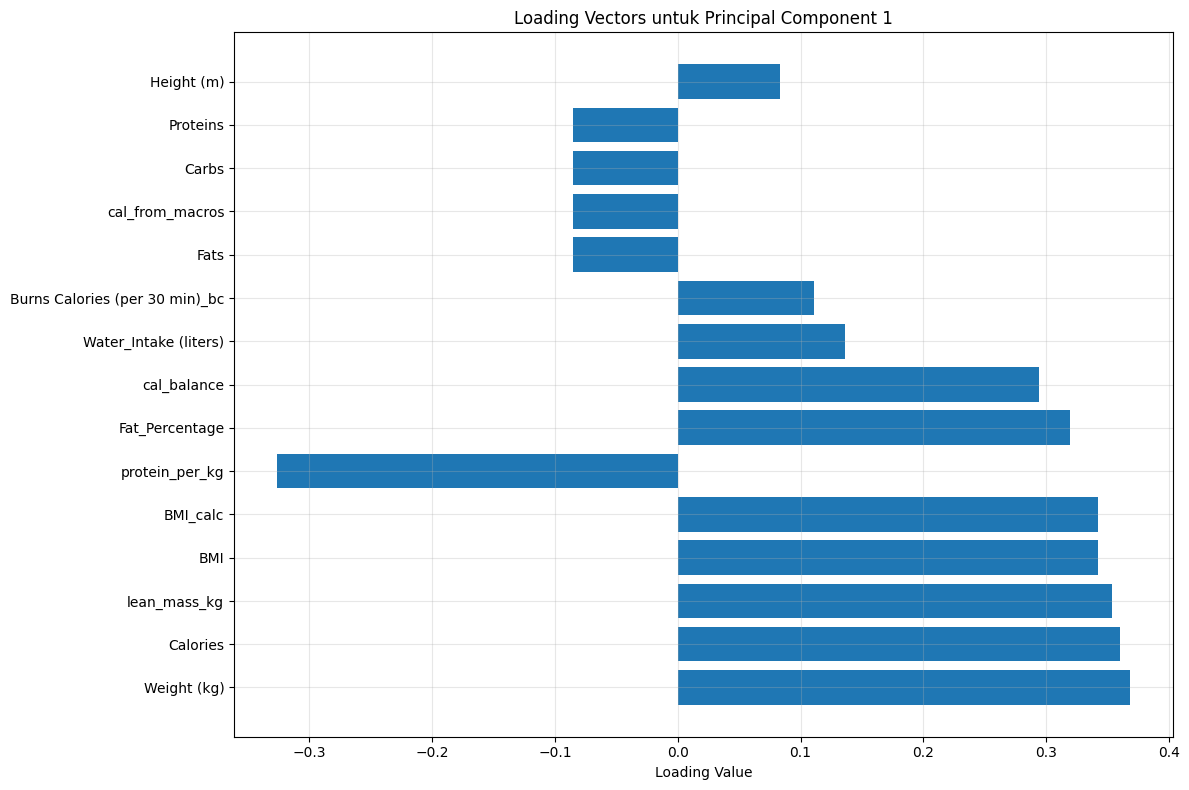

In [63]:
# 5. Analisis loading vectors (koefisien komponen)
components_df = pd.DataFrame(
    pca_optimal.components_.T,
    columns=[f'PC{i+1}' for i in range(n_components_optimal)],
    index=numerical_features_pca.columns
)

print(f"\n=== LOADING VECTORS (TOP 5 KOMPONEN) ===")
print(components_df.iloc[:, :5].round(3))

# Visualisasi loading vectors untuk komponen pertama
plt.figure(figsize=(12, 8))
n_vars_to_show = min(len(numerical_features_pca.columns), 15)
top_vars = abs(components_df['PC1']).nlargest(n_vars_to_show).index

plt.barh(range(len(top_vars)), components_df.loc[top_vars, 'PC1'])
plt.yticks(range(len(top_vars)), top_vars)
plt.xlabel('Loading Value')
plt.title('Loading Vectors untuk Principal Component 1')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

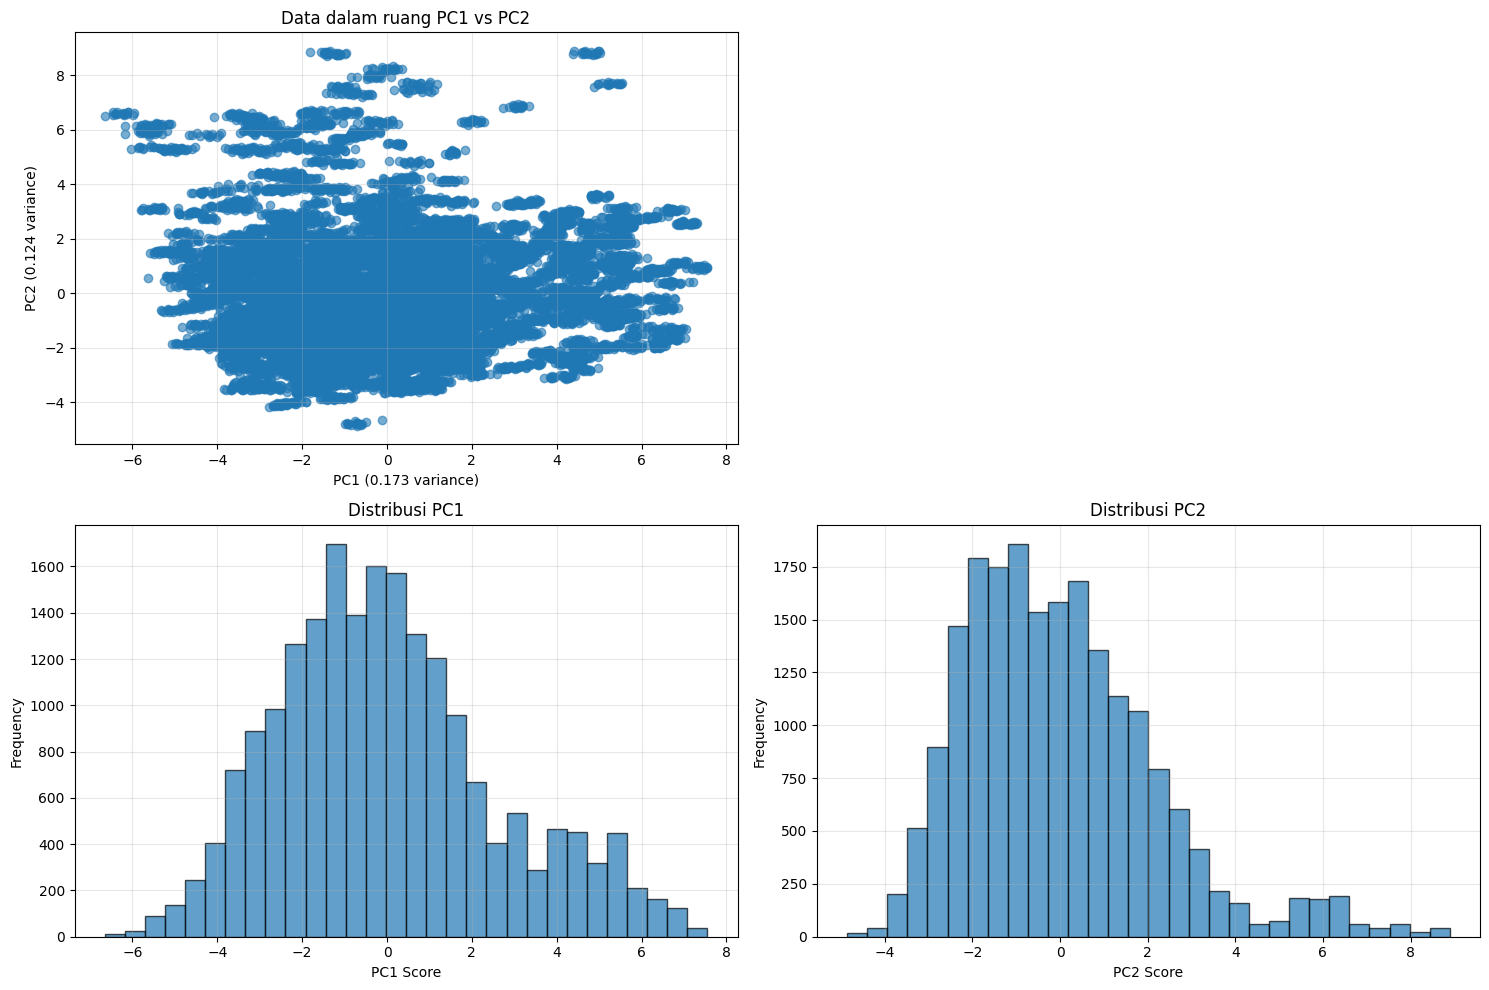

In [64]:
# 6. Visualisasi data dalam ruang PC
if n_components_optimal >= 2:
    # Plot 2D PCA
    plt.figure(figsize=(15, 10))
    
    plt.subplot(2, 2, 1)
    plt.scatter(pca_transformed[:, 0], pca_transformed[:, 1], alpha=0.6)
    plt.xlabel(f'PC1 ({pca_optimal.explained_variance_ratio_[0]:.3f} variance)')
    plt.ylabel(f'PC2 ({pca_optimal.explained_variance_ratio_[1]:.3f} variance)')
    plt.title('Data dalam ruang PC1 vs PC2')
    plt.grid(True, alpha=0.3)
    
    # Plot dengan cluster labels jika tersedia
    if 'Cluster' in final_data.columns:
        plt.subplot(2, 2, 2)
        colors = ['red', 'blue', 'green', 'orange', 'purple']
        for i in range(final_data['Cluster'].nunique()):
            cluster_mask = final_data['Cluster'] == i
            plt.scatter(pca_transformed[cluster_mask, 0], pca_transformed[cluster_mask, 1], 
                       c=colors[i], label=f'Cluster {i}', alpha=0.7)
        plt.xlabel(f'PC1 ({pca_optimal.explained_variance_ratio_[0]:.3f} variance)')
        plt.ylabel(f'PC2 ({pca_optimal.explained_variance_ratio_[1]:.3f} variance)')
        plt.title('PCA dengan Cluster Labels')
        plt.legend()
        plt.grid(True, alpha=0.3)
    
    # Plot distribusi komponen pertama
    plt.subplot(2, 2, 3)
    plt.hist(pca_transformed[:, 0], bins=30, alpha=0.7, edgecolor='black')
    plt.xlabel('PC1 Score')
    plt.ylabel('Frequency')
    plt.title('Distribusi PC1')
    plt.grid(True, alpha=0.3)
    
    # Plot distribusi komponen kedua
    plt.subplot(2, 2, 4)
    plt.hist(pca_transformed[:, 1], bins=30, alpha=0.7, edgecolor='black')
    plt.xlabel('PC2 Score')
    plt.ylabel('Frequency')
    plt.title('Distribusi PC2')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

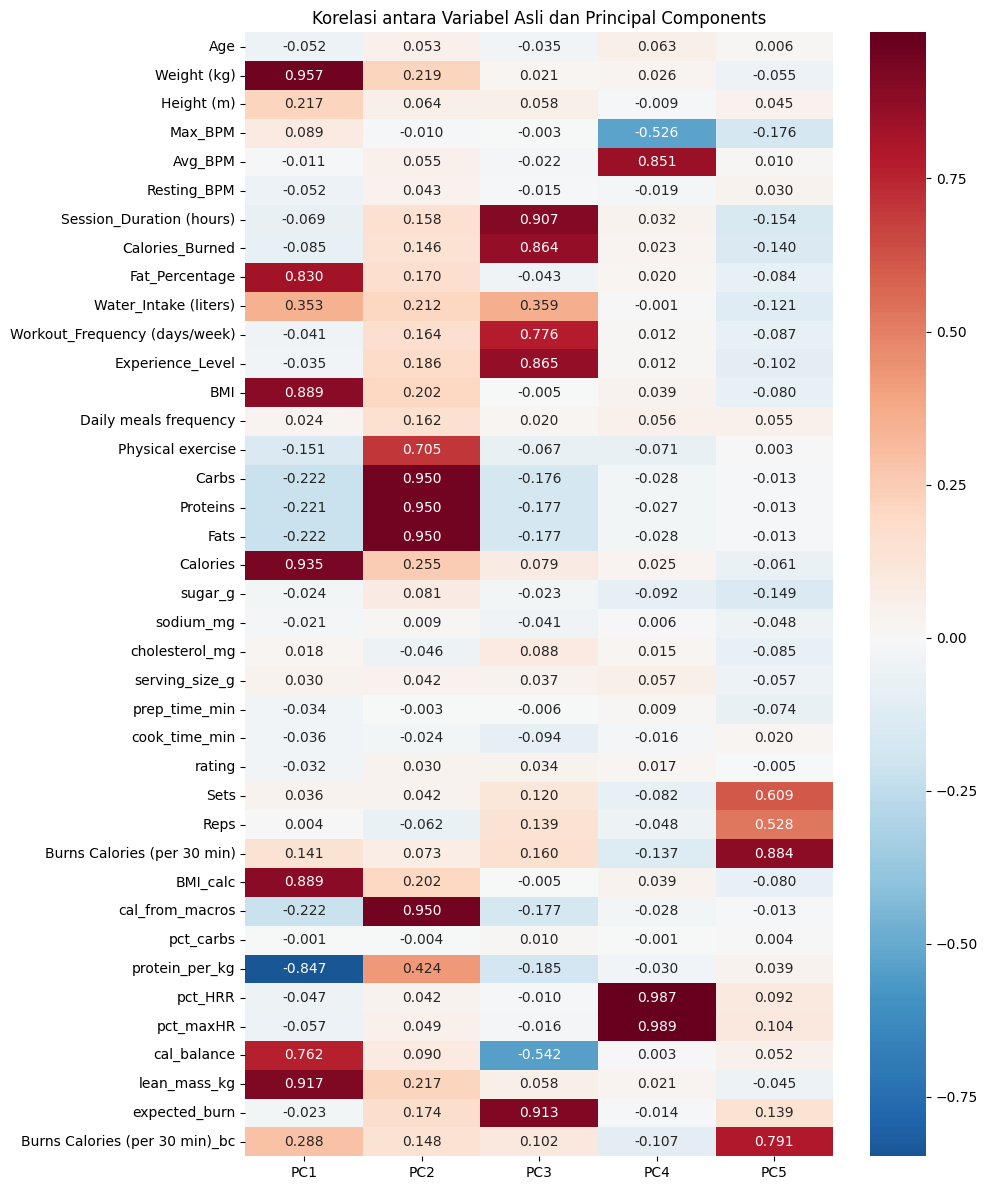

In [65]:
# 7. Heatmap korelasi antara variabel asli dan komponen utama
correlation_with_pc = pd.DataFrame()
for i in range(min(5, n_components_optimal)):  # Hanya 5 komponen pertama
    pc_scores = pca_transformed[:, i]
    correlations = []
    for col in numerical_features_pca.columns:
        corr = np.corrcoef(numerical_features_pca[col], pc_scores)[0, 1]
        correlations.append(corr)
    correlation_with_pc[f'PC{i+1}'] = correlations

correlation_with_pc.index = numerical_features_pca.columns

# Visualisasi heatmap
plt.figure(figsize=(10, 12))
sns.heatmap(correlation_with_pc, 
            annot=True, 
            cmap='RdBu_r', 
            center=0,
            fmt='.3f')
plt.title('Korelasi antara Variabel Asli dan Principal Components')
plt.tight_layout()
plt.show()

In [66]:
# 8. Interpretasi komponen utama
for i in range(min(3, n_components_optimal)):  # Interpretasi 3 komponen pertama
    print(f"\n--- PRINCIPAL COMPONENT {i+1} ---")
    print(f"Explained Variance: {pca_optimal.explained_variance_ratio_[i]:.4f} ({pca_optimal.explained_variance_ratio_[i]*100:.2f}%)")
    
    # Variabel dengan loading tertinggi (positif dan negatif)
    pc_loadings = components_df[f'PC{i+1}']
    top_positive = pc_loadings.nlargest(5)
    top_negative = pc_loadings.nsmallest(5)
    
    print(f"Top 5 variabel dengan loading positif tertinggi:")
    for var, loading in top_positive.items():
        print(f"  {var}: {loading:.3f}")
    
    print(f"Top 5 variabel dengan loading negatif tertinggi:")
    for var, loading in top_negative.items():
        print(f"  {var}: {loading:.3f}")


--- PRINCIPAL COMPONENT 1 ---
Explained Variance: 0.1727 (17.27%)
Top 5 variabel dengan loading positif tertinggi:
  Weight (kg): 0.369
  Calories: 0.360
  lean_mass_kg: 0.354
  BMI: 0.342
  BMI_calc: 0.342
Top 5 variabel dengan loading negatif tertinggi:
  protein_per_kg: -0.326
  Fats: -0.085
  cal_from_macros: -0.085
  Carbs: -0.085
  Proteins: -0.085

--- PRINCIPAL COMPONENT 2 ---
Explained Variance: 0.1240 (12.40%)
Top 5 variabel dengan loading positif tertinggi:
  cal_from_macros: 0.432
  Proteins: 0.432
  Carbs: 0.432
  Fats: 0.432
  Physical exercise: 0.321
Top 5 variabel dengan loading negatif tertinggi:
  Reps: -0.028
  cholesterol_mg: -0.021
  cook_time_min: -0.011
  Max_BPM: -0.005
  pct_carbs: -0.002

--- PRINCIPAL COMPONENT 3 ---
Explained Variance: 0.1141 (11.41%)
Top 5 variabel dengan loading positif tertinggi:
  expected_burn: 0.433
  Session_Duration (hours): 0.430
  Experience_Level: 0.410
  Calories_Burned: 0.410
  Workout_Frequency (days/week): 0.368
Top 5 variabe

Rekonstruksi dengan 2 komponen - MSE: 0.703344
Rekonstruksi dengan 5 komponen - MSE: 0.453094
Rekonstruksi dengan 10 komponen - MSE: 0.296850
Rekonstruksi dengan 21 komponen - MSE: 0.048873


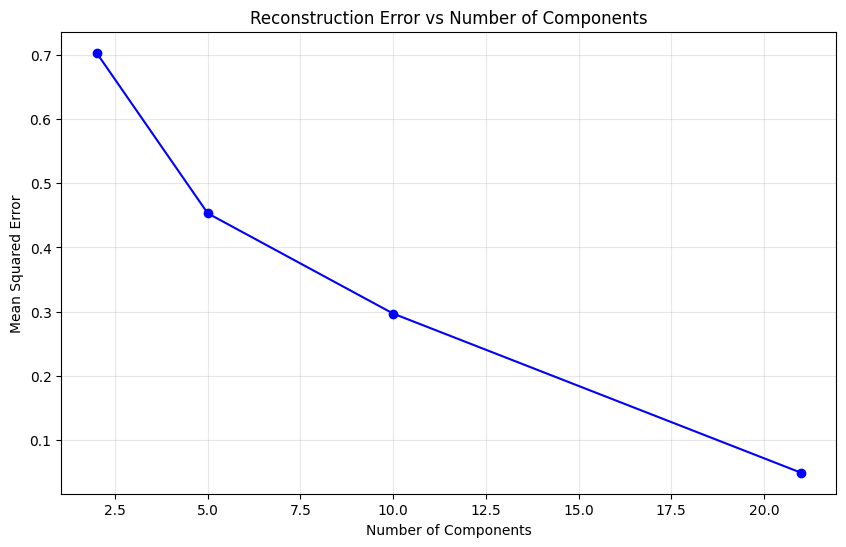

In [67]:
# 9. Rekonstruksi data dan analisis error
# Rekonstruksi dengan beberapa komponen berbeda
n_components_test = [2, 5, 10, n_components_optimal]
reconstruction_errors = []

for n_comp in n_components_test:
    if n_comp <= n_components_optimal:
        # PCA dengan n komponen
        pca_test = PCA(n_components=n_comp)
        transformed = pca_test.fit_transform(scaled_data_pca)
        
        # Rekonstruksi
        reconstructed = pca_test.inverse_transform(transformed)
        
        # Hitung error (MSE)
        mse = np.mean((scaled_data_pca - reconstructed) ** 2)
        reconstruction_errors.append(mse)
        
        print(f"Rekonstruksi dengan {n_comp} komponen - MSE: {mse:.6f}")

# Plot reconstruction error
plt.figure(figsize=(10, 6))
plt.plot(n_components_test[:len(reconstruction_errors)], reconstruction_errors, 'bo-')
plt.xlabel('Number of Components')
plt.ylabel('Mean Squared Error')
plt.title('Reconstruction Error vs Number of Components')
plt.grid(True, alpha=0.3)
plt.show()

In [70]:
# 10. Simpan hasil PCA
pca_results = pd.DataFrame(pca_transformed, 
                          columns=[f'PC{i+1}' for i in range(n_components_optimal)])

# Tambahkan informasi tambahan
pca_results['Original_Index'] = final_data.index
if 'Cluster' in final_data.columns:
    pca_results['Cluster'] = final_data['Cluster'].values

print(f"Data PCA shape: {pca_results.shape}")
print(f"Sample data PCA:")
pca_results.head()

Data PCA shape: (20000, 22)
Sample data PCA:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,Original_Index
0,-0.959115,0.033119,-0.929382,0.450655,0.390757,-1.681490,0.845770,-0.552904,0.398745,0.734218,...,0.455718,0.529189,1.918342,1.859001,0.843129,0.627922,0.608866,1.301520,1.961770,0
1,-1.446188,-1.318700,1.488845,-1.430629,-0.090094,-1.979128,0.758360,-0.321303,0.491561,0.784659,...,-1.801098,0.099713,1.217393,0.745417,2.719113,-0.534990,-0.970242,-1.439345,0.203226,1
2,-1.319292,-1.072622,-1.748942,-1.852951,1.261842,-0.128818,-0.580997,1.710553,-0.171426,-0.665540,...,-1.722259,-0.405989,0.324657,-1.849353,-0.954138,1.246320,-0.134328,0.526162,0.282667,2
3,3.101680,-1.138939,0.268669,0.619046,-0.516476,-0.917281,-1.718874,-0.931565,-0.600550,-0.025492,...,1.162433,0.435378,-0.895308,0.122137,-1.737482,-1.844723,-0.752944,-1.023799,0.729729,3
4,-4.115897,3.137483,-0.900721,-0.561363,-0.607815,1.887837,1.868014,-0.647694,-0.175026,0.968633,...,0.968011,0.246830,0.730930,0.032942,0.139912,-0.397897,-1.268475,0.964391,0.757174,4


In [71]:
print(f"Jumlah variabel asli: {numerical_features_pca.shape[1]}")
print(f"Jumlah komponen utama: {n_components_optimal}")
print(f"Reduksi dimensi: {(1 - n_components_optimal/numerical_features_pca.shape[1])*100:.1f}%")
print(f"Variance yang dipertahankan: {pca_optimal.explained_variance_ratio_.sum()*100:.2f}%")

Jumlah variabel asli: 39
Jumlah komponen utama: 21
Reduksi dimensi: 46.2%
Variance yang dipertahankan: 95.11%
